# Integrated Gas-Solar Hybrid Asset Model — Nigeria
## A Three-Equation SUR System with Correlated Monte Carlo and Project Finance

**Profile:** BSc Geology | MSc Petroleum & Energy Engineering | MSc Financial Engineering | Solar experience

---

## The Analytical Argument

To optimise a gas-solar hybrid energy asset in Nigeria, three quantities must be modelled simultaneously and jointly:

1. **Gas supply price** — what it costs to fuel a gas thermal plant
2. **Gas thermal plant capacity factor** — how much of that plant actually runs
3. **Solar PV capacity factor** — how much the solar component generates

These are not independent. They share structural drivers: FX crises raise O&M costs for both technologies. Grid instability curtails both simultaneously, if solar connects to the National grid. Sector liquidity failures reduce offtake for both. When NLNG utilisation rises, domestic gas supply tightens and power output falls (Nigerias Domestic Gas Obligation Regulation tries to solve this) — while solar is unaffected but faces the same grid evacuation bottleneck.

Modelling them independently ignores this cross-equation error correlation. This notebook estimates all three equations jointly as a **Seemingly Unrelated Regression (SUR/FGLS)** system, simulates them jointly under a correlated stochastic framework, and feeds the joint outputs into a project finance waterfall to find the Sharpe-optimal gas-solar allocation and hedge ratio.

---

## Full Notebook Flow

```
PART 1 — FOUNDATIONS
  Cell 0:  Imports and configuration
  Cell 1:  Data assembly and variable catalogue (30+ variables, 8 categories)
  Cell 2:  Stationarity testing (ADF — every variable)
  Cell 3:  Cointegration testing (Engle-Granger — Equation 1)

PART 2 — THE THREE-EQUATION REGRESSION SYSTEM
  Cell 4:  Equation 1 — Gas price (OLS + NW-HAC SE)
  Cell 5:  Full regressor universe for Eq 2 and Eq 3
  Cell 6:  Multicollinearity audit (VIF — documenting the problem)
  Cell 7:  PCA factor reduction (solving multicollinearity — 20+ → orthogonal factors)
  Cell 8:  Equation 2 — Gas thermal CF (OLS on PCA factors + NW-HAC)
  Cell 9:  Equation 3 — Solar CF (OLS on PCA factors + NW-HAC)
  Cell 10: Cross-equation residual correlation test (SUR motivation)
  Cell 11: SUR estimation via FGLS (joint efficiency gain documented)

PART 3 — CORRELATED MONTE CARLO ENGINE
  Cell 12: Market driver covariance and Cholesky decomposition
  Cell 13: Joint path simulation (gas price, gas CF, solar CF from same factors)

PART 4 — PROJECT FINANCE
  Cell 14: Stochastic dispatch and project finance waterfall
  Cell 15: Risk metrics (P10/P50/P90, VaR, CVaR, DSCR)

PART 5 — PORTFOLIO AND HEDGE OPTIMISATION
  Cell 16: Sharpe-optimal gas-solar allocation
  Cell 17: Periodic hedge ratio optimisation

PART 6 — REAL DATA INTEGRATION
  Cell 18: Data pipeline (runnable with graceful fallback)
```

---

## Colour coding
- `# ── PLACEHOLDER ──` = synthetic data; real source documented
- `# ── SUR ──` = new jointly-estimated section
- `# ── FIX ──` = corrected from v1


---
# PART 1 — FOUNDATIONS
## Cell 0 — Imports and Configuration

In [1]:
# ══════════════════════════════════════════════════════════════════════
# CELL 0 — IMPORTS
# pip install pandas numpy matplotlib scipy scikit-learn
# ══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.optimize import minimize
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#F9F9F9',
    'axes.grid':True,'grid.alpha':0.25,
    'axes.spines.top':False,'axes.spines.right':False,'font.size':10
})

START_DATE = '2015-01-01';  END_DATE  = '2025-12-31'
N_SIMS     = 5000;          N_MONTHS  = 120
RANDOM_SEED= 42;            np.random.seed(RANDOM_SEED)

print(f'Config: {N_SIMS:,} sims × {N_MONTHS} months | seed={RANDOM_SEED}')

Config: 5,000 sims × 120 months | seed=42


---
## Cell 1 — Data Assembly and Variable Catalogue

Every variable has a documented source. Synthetic series are flagged `# ── PLACEHOLDER ──` and will be updated as data becomes available.

### Variable catalogue by equation

**Equation 1 — Gas price drivers:**
`ln(brent)`, `ln(usdngn)`, `ln(demand_mw)`, `ttf_jkm`, `nlng_util`

**Equation 2 — Gas thermal CF drivers (8 categories, 20 variables):**

| Category | Variables |
|---|---|
| Gas supply | gas_to_power, domestic_alloc, gas_price (from Eq1), nlng_util, ttf_jkm |
| FX crisis | ln_usdngn, fx_reserves, inflation, receivables |
| LNG exports | jkm_netback |
| Pipeline vandalism | pipeline_down, vandalism_idx, fm_dummy |
| Maintenance | forced_outage, plant_age_gas, eaf |
| Policy | grid_demand_norm, dgso_dummy |
| Transmission | wheeling_cap, freq_collapse, tcn_curtailment |
| Sector liquidity | nbet_pay_ratio, disco_collect, market_shortfall |

**Equation 3 — Solar CF drivers (6 categories, 13 variables):**

| Category | Variables |
|---|---|
| Irradiance | ghi, dni |
| Temperature/season | temp_c, harmattan, precip_mm, aerosol_od |
| Grid evacuation | tcn_curtailment*, freq_collapse*, grid_voltage_dev |
| FX | ln_usdngn* |
| Sector liquidity | nbet_pay_ratio*, disco_collect* |
| Degradation | solar_plant_age |

*Shared with Equation 2 — creates cross-equation error correlation → SUR advantageous


In [2]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 1
# Load reconstructed master panel
# No synthetic fallback required
# ═══════════════════════════════════════════════════════════════════════

import os
# Safety
_RANDOM_SEED = globals().get('RANDOM_SEED', 42)
_START_DATE  = globals().get('START_DATE', '2017-01-01')
_END_DATE    = globals().get('END_DATE', '2026-05-01')

RANDOM_SEED = _RANDOM_SEED
START_DATE  = _START_DATE
END_DATE    = _END_DATE

np.random.seed(RANDOM_SEED)

dates = pd.date_range(
    START_DATE,
    END_DATE,
    freq='MS'
)

# ──────────────────────────────────────────────────────────────
# LOAD RECONSTRUCTED PANEL
# ──────────────────────────────────────────────────────────────

PANEL_PATH = "data/master_panel_reconstructed_v2.csv"

if not os.path.exists(PANEL_PATH):
    raise FileNotFoundError(
        f"{PANEL_PATH} not found. "
        "Run reconstruction engine first."
    )

df = pd.read_csv(
    PANEL_PATH,
    index_col=0,
    parse_dates=True
)

df = df.reindex(dates).ffill().bfill()

# ──────────────────────────────────────────────────────────────
# VARIABLE ALIASES FOR BACKWARD COMPATIBILITY
# ──────────────────────────────────────────────────────────────

if "eaf" not in df.columns and "PAF" in df.columns:
    df["eaf"] = df["PAF"]

if "nbet_pay_ratio" not in df.columns and "nbet_mo_pay_ratio" in df.columns:
    df["nbet_pay_ratio"] = df["nbet_mo_pay_ratio"]

if "disco_collect" not in df.columns and "disco_collect_efficiency" in df.columns:
    df["disco_collect"] = df["disco_collect_efficiency"]


# ──────────────────────────────────────────────────────────────
# CANONICAL VARIABLE NAMES
# ──────────────────────────────────────────────────────────────

rename_map = {}

if "nbet_pay_ratio" in df.columns:
    rename_map["nbet_pay_ratio"] = "nbet_ratio"

if "Total_E_Rec_by_disco" in df.columns:
    rename_map["Total_E_Rec_by_disco"] = "receivables"

df = df.rename(columns=rename_map)

# Create standalone variables expected by old notebook cells

for col in df.columns:
    globals()[col] = df[col].values

In [3]:
df.columns

Index(['brent', 'usdngn', 'ttf_jkm', 'jkm_netback', 'ghi', 'dni', 'temp_c',
       'precip_mm', 'aerosol_od', 'fx_reserves', 'inflation', 'gas_price',
       'harmattan', 'fm_dummy', 'pipeline_down', 'vandalism_idx',
       'plant_age_gas', 'gas_to_power', 'domestic_alloc', 'eaf',
       'Transmission_Loss_factor', 'freq_collapse', 'load_variance', 'ATC&C',
       'Tech_&_commercial_loss', 'collection_loss', 'receivables',
       'Total_E_Billed_by_Disco', 'Total_E_paid_to_Disco', 'market_shortfall',
       'disco_collect', 'Billing_efficiency', 'nbet_ratio', 'gas_cf',
       'solar_cf', 'Gas_constraint', 'Distribution_constraint',
       'Transmission_constraint'],
      dtype='str')

Variables found:
['gas_price', 'gas_cf', 'solar_cf', 'brent', 'usdngn', 'ttf_jkm', 'jkm_netback', 'inflation', 'fx_reserves', 'gas_to_power', 'domestic_alloc', 'eaf', 'pipeline_down', 'Gas_constraint', 'Transmission_constraint', 'Distribution_constraint', 'market_shortfall', 'ATC&C', 'nbet_ratio', 'freq_collapse', 'ghi', 'dni', 'temp_c', 'precip_mm', 'aerosol_od', 'harmattan']

gas_price
count    132.000000
mean       1.946061
std        0.189824
min        1.750000
25%        1.750000
50%        2.050000
75%        2.100000
max        2.180000
Name: gas_price, dtype: float64
Skewness: 0.02
Kurtosis: -1.86


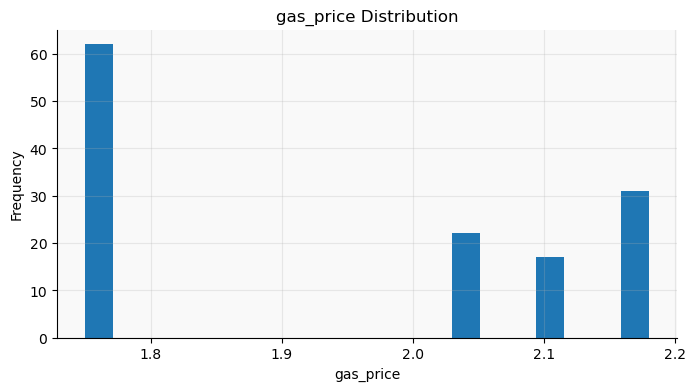

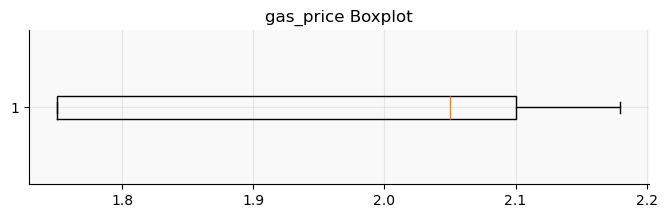


gas_cf
count    132.000000
mean      27.405734
std        3.270559
min       22.810000
25%       24.980000
50%       27.500000
75%       29.682500
max       34.660000
Name: gas_cf, dtype: float64
Skewness: 0.18
Kurtosis: -0.66


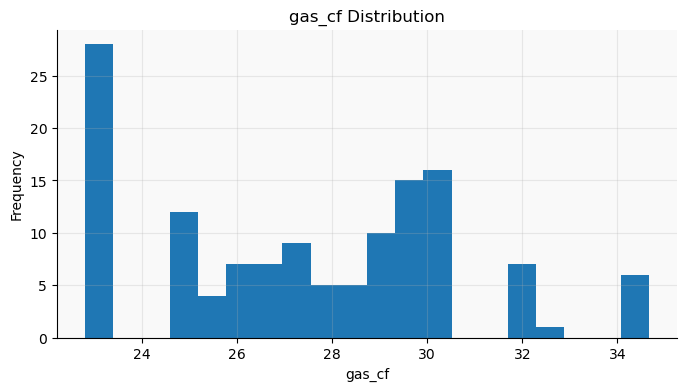

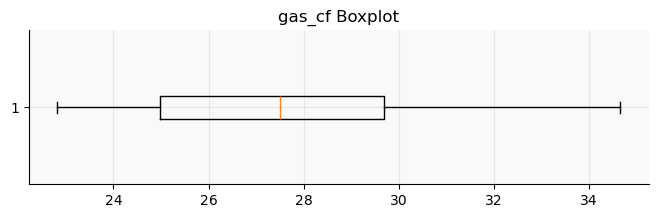


solar_cf
count    132.000000
mean      16.761364
std        3.241234
min       12.500000
25%       13.500000
50%       16.250000
75%       19.000000
max       23.000000
Name: solar_cf, dtype: float64
Skewness: 0.37
Kurtosis: -1.14


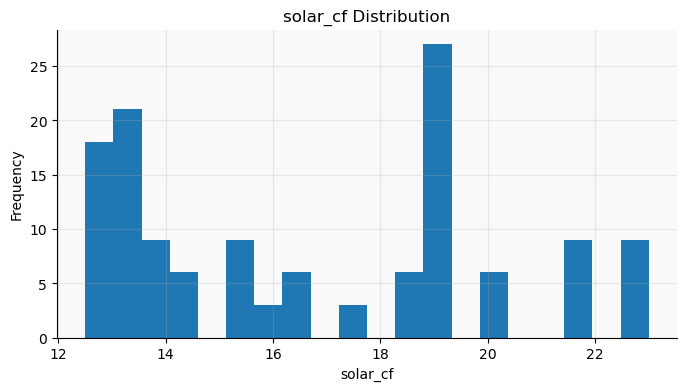

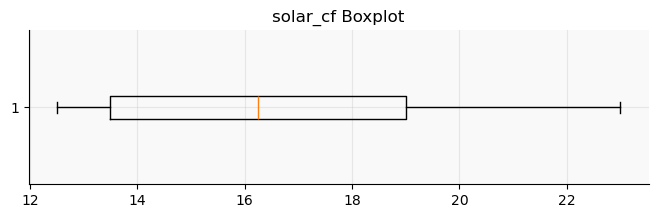


brent
count    132.000000
mean      67.701431
std       16.830220
min       29.854346
25%       54.576667
50%       65.363750
75%       78.548511
max      117.909900
Name: brent, dtype: float64
Skewness: 0.54
Kurtosis: 0.65


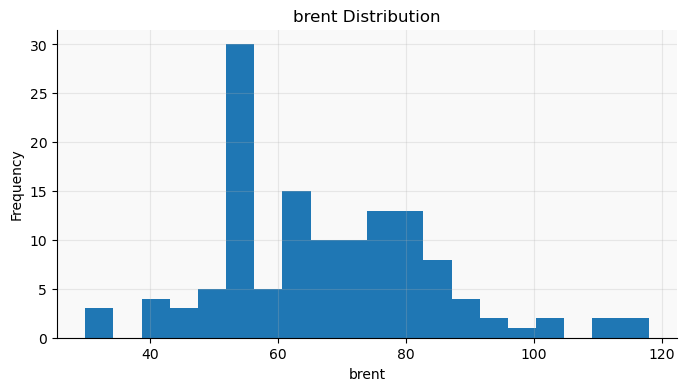

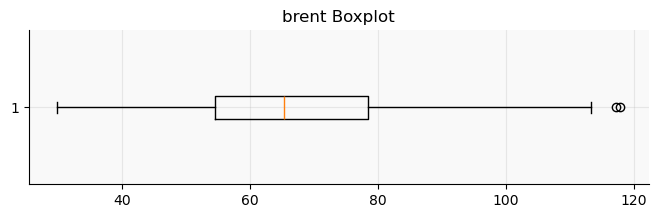


usdngn
count     132.000000
mean      615.586803
std       462.434023
min       305.000000
25%       305.000000
50%       369.000000
75%       683.750000
max      1601.481968
Name: usdngn, dtype: float64
Skewness: 1.27
Kurtosis: -0.14


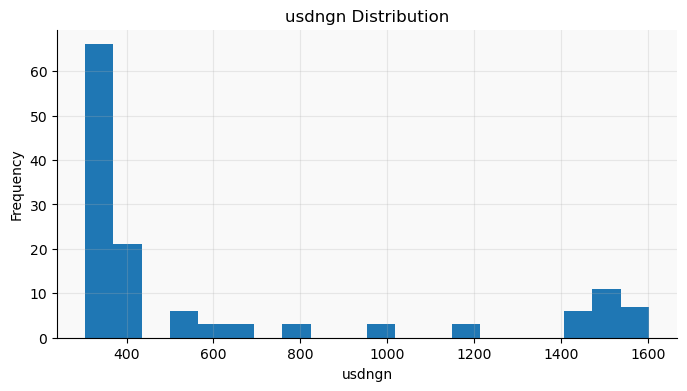

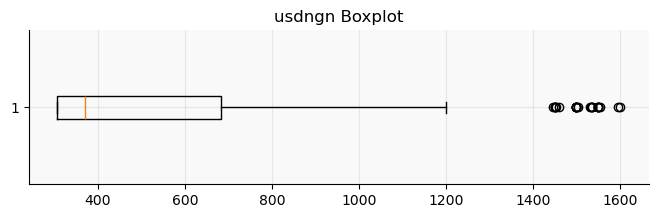


ttf_jkm
count    132.000000
mean      11.351320
std       10.604843
min        1.769762
25%        6.144349
50%        7.204580
75%       11.693664
max       56.304489
Name: ttf_jkm, dtype: float64
Skewness: 2.45
Kurtosis: 6.10


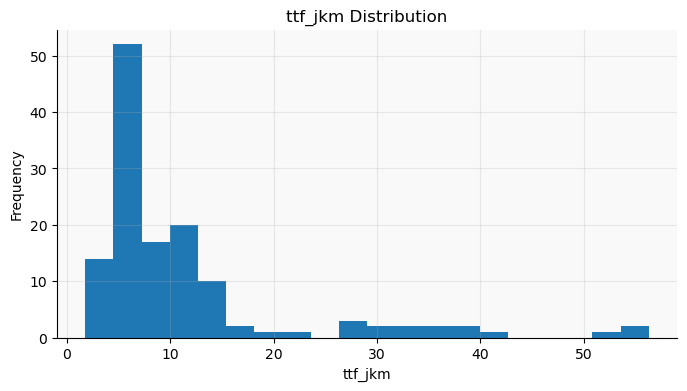

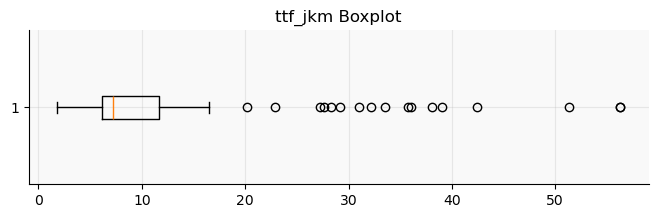


jkm_netback
count    132.000000
mean      11.139054
std        3.334388
min        6.211493
25%        8.269091
50%       10.258489
75%       12.625065
max       21.614642
Name: jkm_netback, dtype: float64
Skewness: 1.25
Kurtosis: 1.53


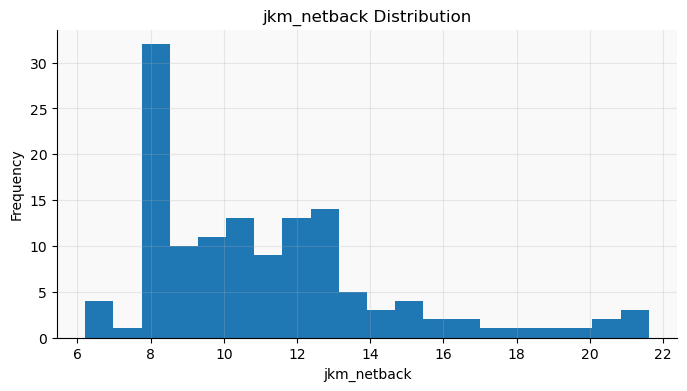

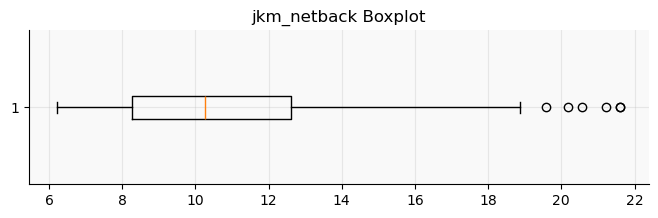


inflation
count    132.000000
mean      18.684828
std        6.772261
min       11.270000
25%       14.505000
50%       16.400000
75%       20.482500
max       33.242097
Name: inflation, dtype: float64
Skewness: 1.16
Kurtosis: 0.18


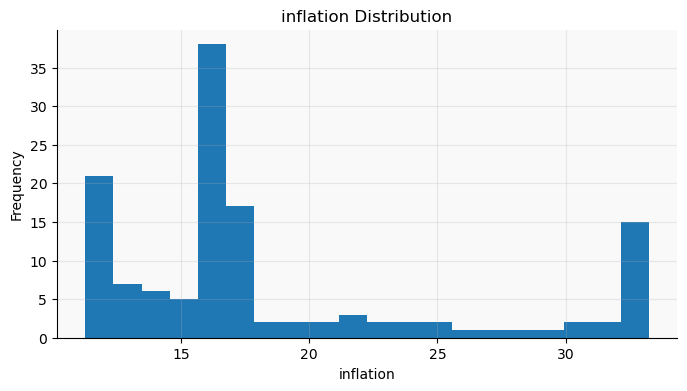

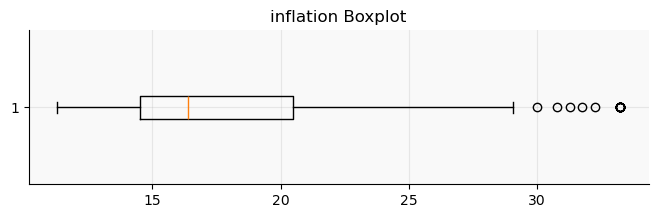


fx_reserves
count    132.000000
mean      36.159462
std        5.578916
min       28.174227
25%       32.431807
50%       36.031455
75%       39.907351
max       47.788529
Name: fx_reserves, dtype: float64
Skewness: 0.13
Kurtosis: -0.87


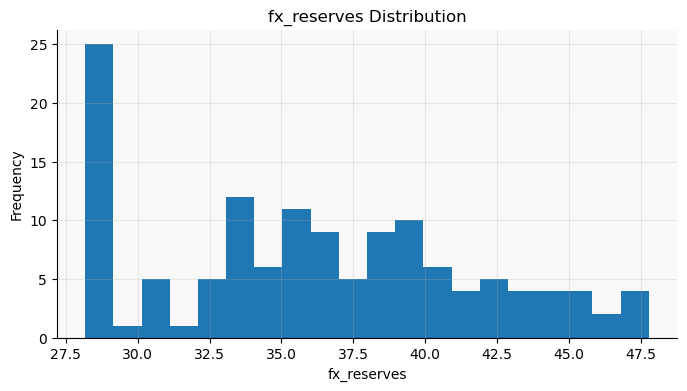

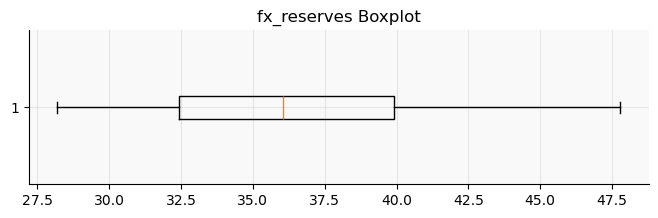


gas_to_power
count      132.000000
mean     27146.739551
std        569.652474
min      23782.360000
25%      26973.877270
50%      27313.288890
75%      27494.997150
max      27722.197480
Name: gas_to_power, dtype: float64
Skewness: -3.17
Kurtosis: 13.96


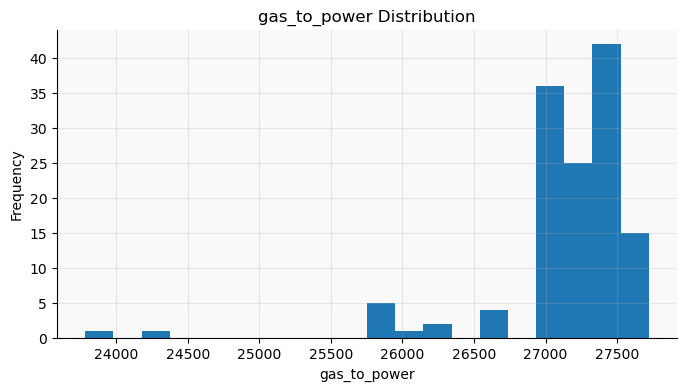

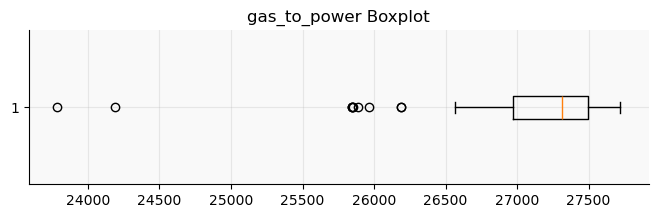


domestic_alloc
count      132.000000
mean     30129.722544
std      19005.833733
min          0.000000
25%      21331.292708
50%      32099.912465
75%      39105.697790
max      84421.043310
Name: domestic_alloc, dtype: float64
Skewness: 0.43
Kurtosis: 0.60


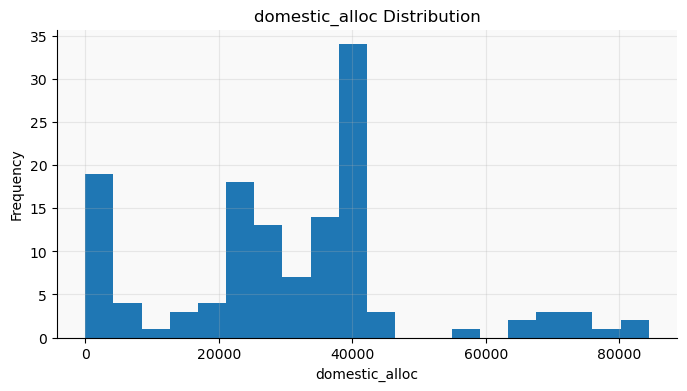

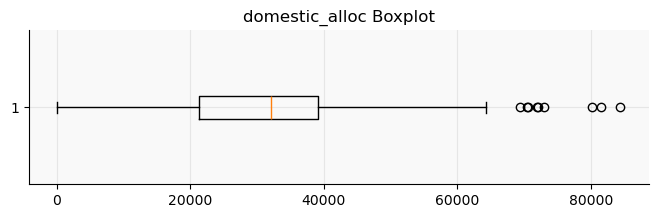


eaf
count    132.000000
mean      45.818217
std       13.016966
min       27.490000
25%       33.280000
50%       43.050000
75%       61.645713
max       64.700000
Name: eaf, dtype: float64
Skewness: 0.39
Kurtosis: -1.41


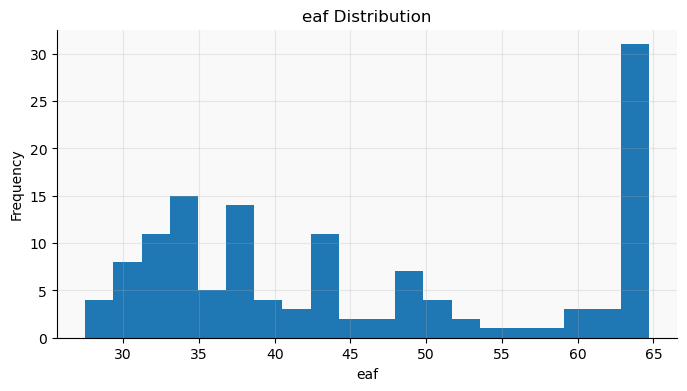

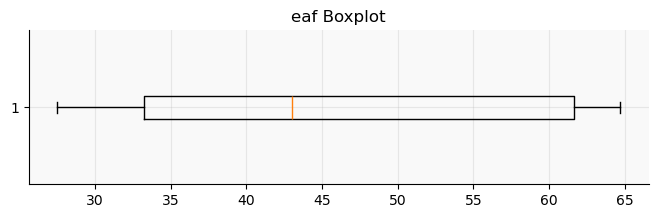


pipeline_down
count    132.000000
mean       6.250000
std        2.155678
min        3.000000
25%        4.000000
50%        7.000000
75%        8.000000
max       11.000000
Name: pipeline_down, dtype: float64
Skewness: 0.02
Kurtosis: -1.21


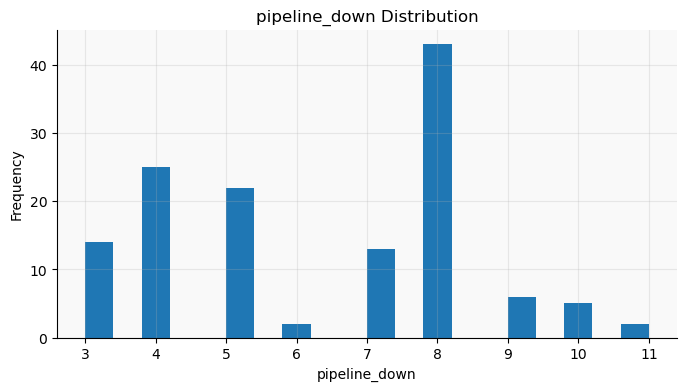

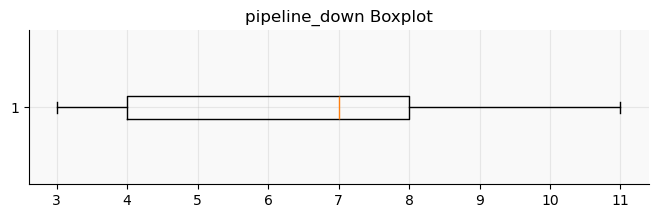


Gas_constraint
count    1.320000e+02
mean     1.127652e+06
std      8.902601e+05
min      0.000000e+00
25%      4.298178e+05
50%      1.329475e+06
75%      1.452000e+06
max      4.739451e+06
Name: Gas_constraint, dtype: float64
Skewness: 0.90
Kurtosis: 1.66


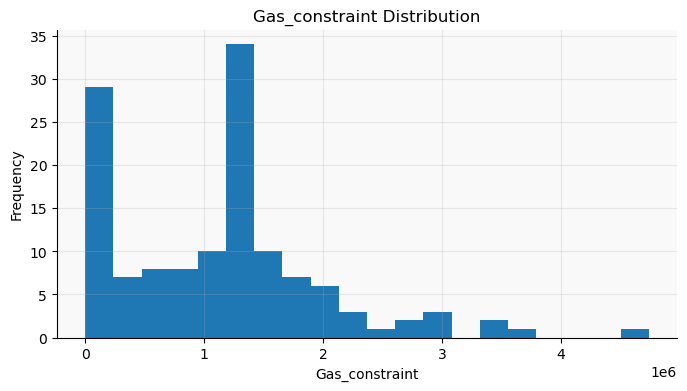

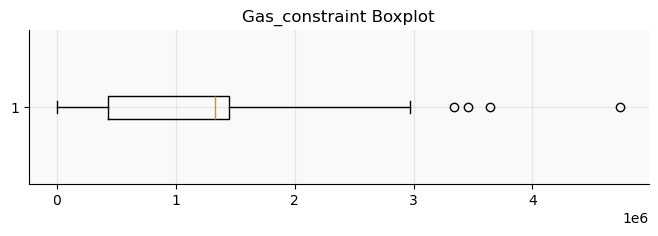


Transmission_constraint
count       132.000000
mean      59599.677159
std       30646.480971
min           0.000000
25%       37200.000000
50%       59683.893800
75%       74344.913953
max      148800.000000
Name: Transmission_constraint, dtype: float64
Skewness: 0.33
Kurtosis: 1.11


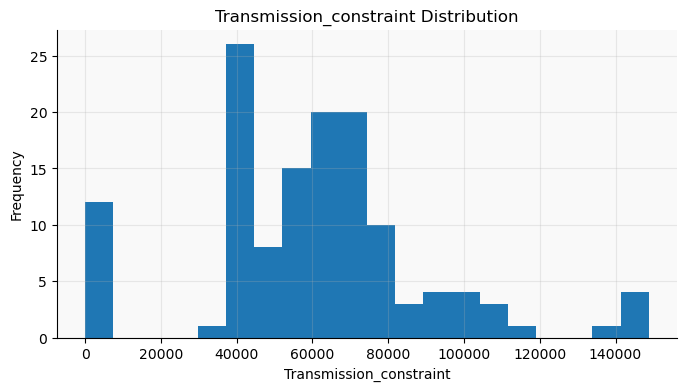

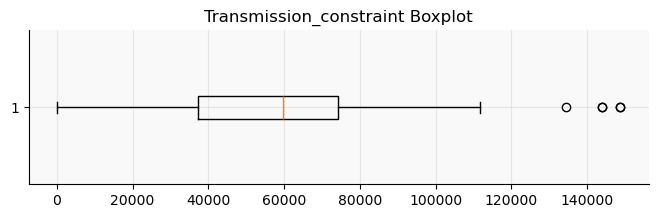


Distribution_constraint
count    1.320000e+02
mean     6.377935e+06
std      1.578868e+07
min      0.000000e+00
25%      7.440000e+04
50%      9.949421e+05
75%      2.326204e+06
max      5.913875e+07
Name: Distribution_constraint, dtype: float64
Skewness: 2.81
Kurtosis: 6.22


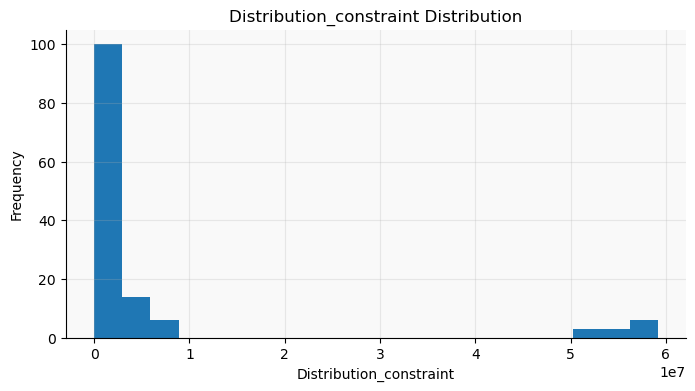

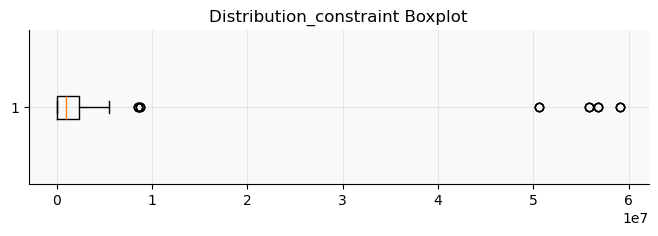


market_shortfall
count    1.320000e+02
mean     5.722014e+10
std      4.104253e+10
min      9.973333e+09
25%      2.862500e+10
50%      4.372598e+10
75%      7.140555e+10
max      1.910000e+11
Name: market_shortfall, dtype: float64
Skewness: 1.81
Kurtosis: 3.09


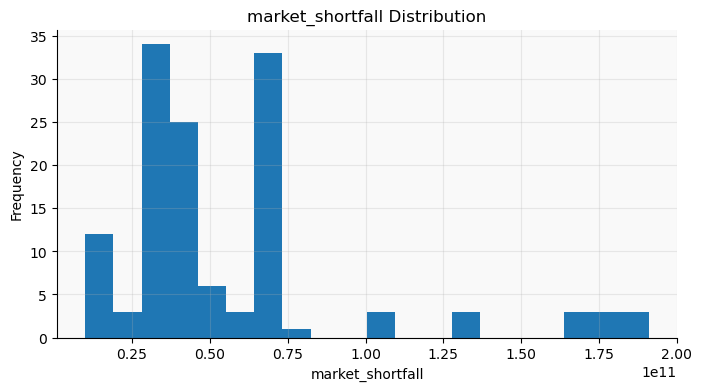

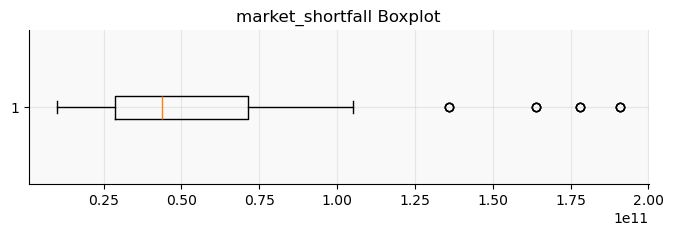


ATC&C
count    132.000000
mean      46.830919
std        6.493546
min       33.270000
25%       42.000000
50%       46.850000
75%       54.100000
max       56.000000
Name: ATC&C, dtype: float64
Skewness: -0.38
Kurtosis: -0.90


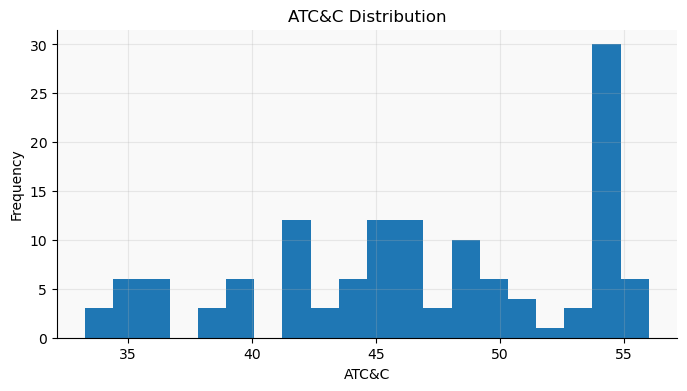

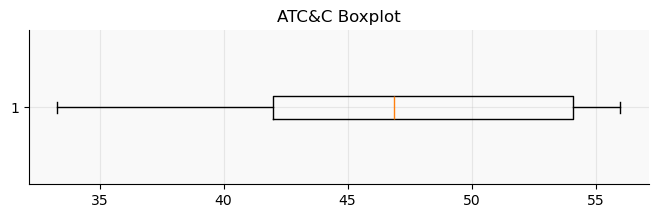


nbet_ratio
count    132.000000
mean      58.222746
std       23.012147
min       18.250000
25%       42.000000
50%       45.000000
75%       77.460000
max       96.930000
Name: nbet_ratio, dtype: float64
Skewness: 0.25
Kurtosis: -1.37


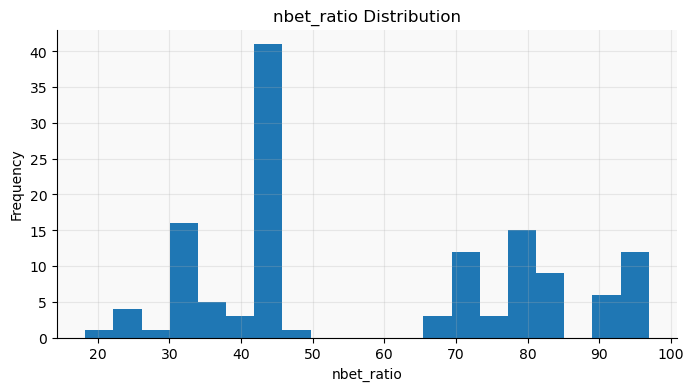

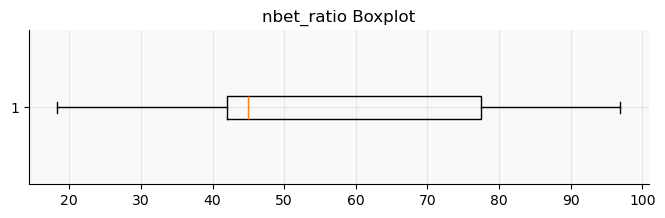


freq_collapse
count    132.000000
mean       1.750000
std        2.235641
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max        6.000000
Name: freq_collapse, dtype: float64
Skewness: 1.19
Kurtosis: -0.25


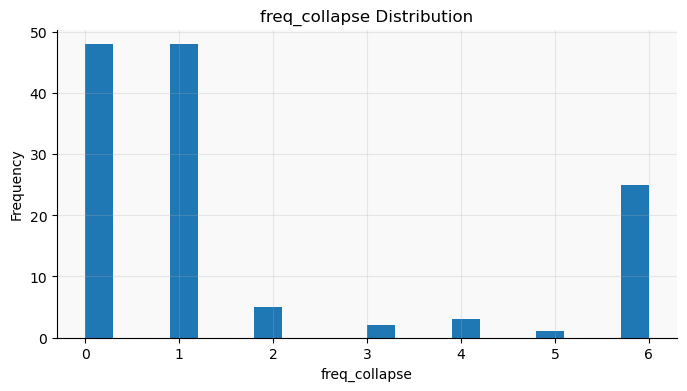

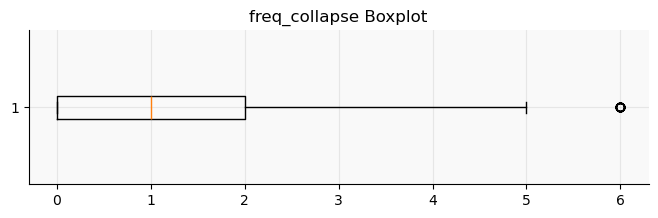


ghi
count    132.000000
mean       5.290936
std        0.613740
min        3.600440
25%        5.038325
50%        5.312400
75%        5.751525
max        6.264850
Name: ghi, dtype: float64
Skewness: -0.92
Kurtosis: 0.39


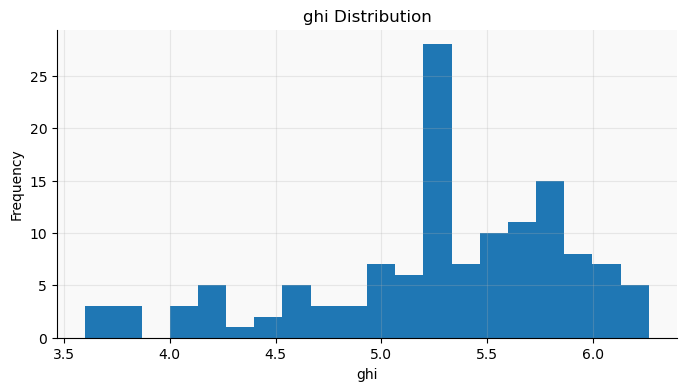

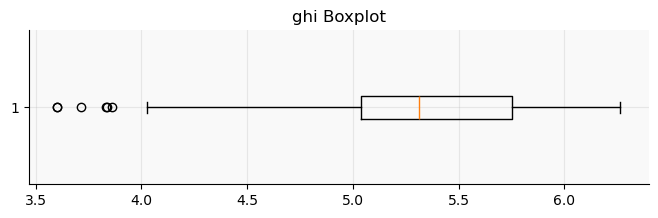


dni
count    132.000000
mean       3.026376
std        1.186322
min        0.892970
25%        2.142575
50%        3.188150
75%        3.435250
max        5.971370
Name: dni, dtype: float64
Skewness: 0.35
Kurtosis: -0.19


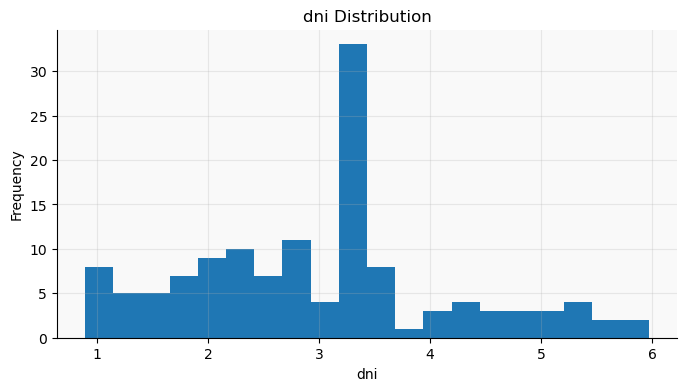

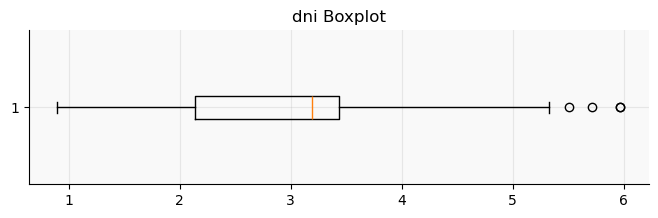


temp_c
count    132.000000
mean      25.778771
std        1.725758
min       22.880900
25%       24.810000
50%       25.200000
75%       26.512500
max       30.798000
Name: temp_c, dtype: float64
Skewness: 1.07
Kurtosis: 0.72


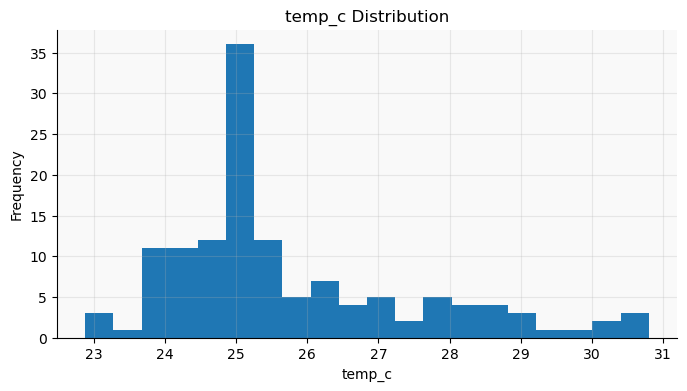

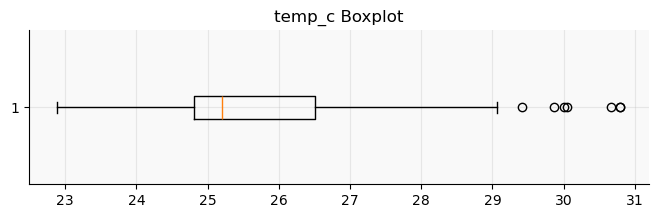


precip_mm
count    132.000000
mean      83.471555
std      104.541025
min        0.000000
25%        0.000000
50%       26.970000
75%      151.125000
max      387.642600
Name: precip_mm, dtype: float64
Skewness: 1.14
Kurtosis: 0.34


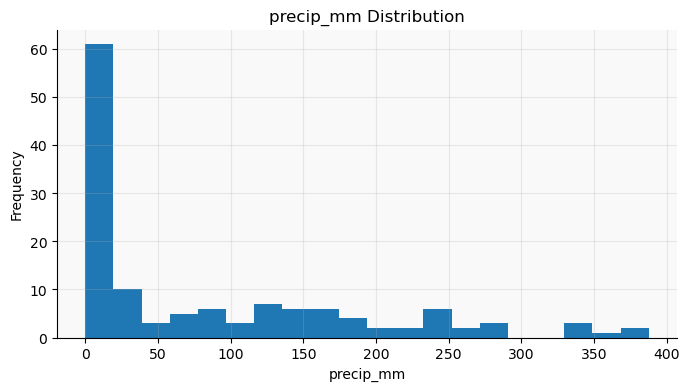

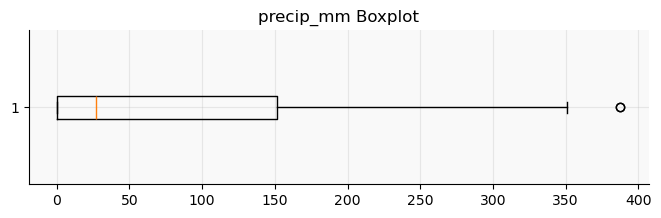


aerosol_od
count    132.000000
mean       0.563371
std        0.162603
min        0.283000
25%        0.450000
50%        0.540000
75%        0.690000
max        1.129000
Name: aerosol_od, dtype: float64
Skewness: 0.53
Kurtosis: 0.27


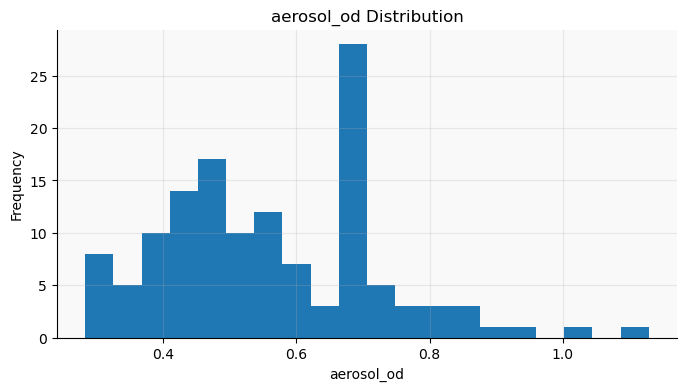

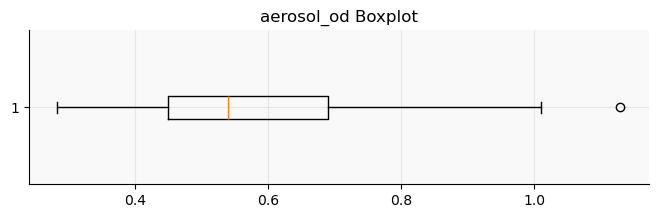


harmattan
count    132.000000
mean       0.522727
std        0.501386
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: harmattan, dtype: float64
Skewness: -0.09
Kurtosis: -2.02


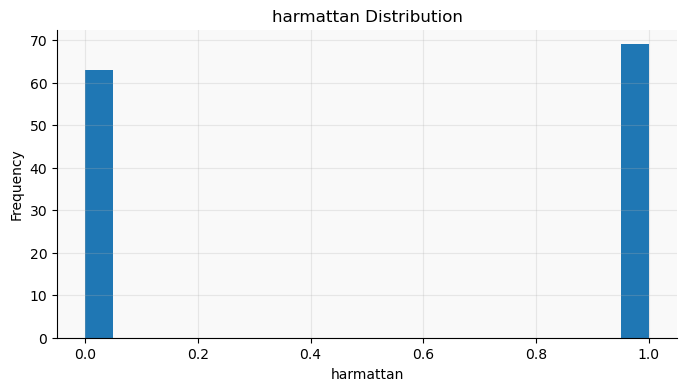

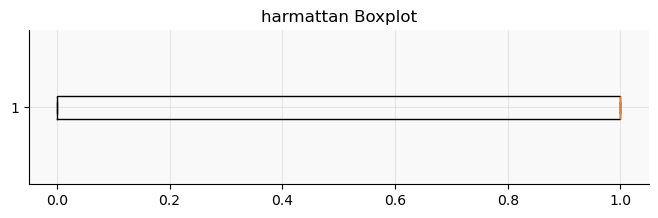

In [4]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 1A — DISTRIBUTION DIAGNOSTICS
# Review distributions before any outlier treatment
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

# Variables likely to contain operational outliers
review_vars = [

    # DEPENDENT VARIABLES
    'gas_price',
    'gas_cf',
    'solar_cf',

    # GAS MARKET
    'brent',
    'usdngn',
    'ttf_jkm',
    'jkm_netback',
    'inflation',
    'fx_reserves',

    # GAS CF DRIVERS
    'gas_to_power',
    'domestic_alloc',
    'eaf',
    'pipeline_down',

    # CONSTRAINTS
    'Gas_constraint',
    'Transmission_constraint',
    'Distribution_constraint',

    # POWER MARKET
    'market_shortfall',
    'ATC&C',
    'nbet_ratio',
    'freq_collapse',

    # SOLAR RESOURCE
    'ghi',
    'dni',
    'temp_c',
    'precip_mm',
    'aerosol_od',
    'harmattan'
]

available_vars = [v for v in review_vars if v in df.columns]

print("Variables found:")
print(available_vars)
    
for var in available_vars:

    s = pd.to_numeric(df[var], errors='coerce').dropna()

    if len(s) < 10:
        continue

    print('\n' + '='*70)
    print(var)

    print(s.describe())

    print(f'Skewness: {s.skew():.2f}')
    print(f'Kurtosis: {s.kurtosis():.2f}')

    plt.figure(figsize=(8,4))
    plt.hist(s, bins=20)
    plt.title(f'{var} Distribution')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.show()

    plt.figure(figsize=(8,2))
    plt.boxplot(s, vert=False)
    plt.title(f'{var} Boxplot')
    plt.show()

In [5]:
# ═══════════════════════════════════════════════════════════════════════
# OUTLIER DIAGNOSTICS
# ═══════════════════════════════════════════════════════════════════════

review_vars = [
    'solar_cf',
    'gas_cf',
    'ghi',
    'dni',
    'temp_c',
    'precip_mm',
    'aerosol_od',
    'nbet_ratio',
    'receivables'
]

for var in review_vars:

    if var not in df.columns:
        continue

    s = pd.to_numeric(df[var], errors='coerce').dropna()

    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((s < lower) | (s > upper)).sum()

    print(
        f"{var:<15} "
        f"Outliers={outliers:>3} "
        f"({100*outliers/len(s):.1f}%)"
    )

solar_cf        Outliers=  0 (0.0%)
gas_cf          Outliers=  0 (0.0%)
ghi             Outliers=  6 (4.5%)
dni             Outliers=  4 (3.0%)
temp_c          Outliers=  7 (5.3%)
precip_mm       Outliers=  2 (1.5%)
aerosol_od      Outliers=  1 (0.8%)
nbet_ratio      Outliers=  0 (0.0%)
receivables     Outliers= 38 (28.8%)


In [6]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 1A — DESCRIPTIVE STATISTICS
# Review all variables in master dataframe
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd

print("=" * 80)
print("DESCRIPTIVE STATISTICS")
print("=" * 80)

# Numeric columns only
num_cols = df.select_dtypes(include=[np.number]).columns

desc_stats = pd.DataFrame(index=num_cols)

desc_stats['count'] = df[num_cols].count()
desc_stats['missing'] = df[num_cols].isna().sum()
desc_stats['mean'] = df[num_cols].mean()
desc_stats['median'] = df[num_cols].median()
desc_stats['std'] = df[num_cols].std()
desc_stats['min'] = df[num_cols].min()
desc_stats['max'] = df[num_cols].max()
desc_stats['skew'] = df[num_cols].skew()
desc_stats['kurtosis'] = df[num_cols].kurt()

# Round for readability
desc_stats = desc_stats.round(4)

print(desc_stats)

# Save for thesis documentation
desc_stats.to_csv('descriptive_statistics.csv')

print("\nSaved: descriptive_statistics.csv")
print(f"Variables analysed: {len(num_cols)}")

DESCRIPTIVE STATISTICS
                          count  missing          mean        median  \
brent                       132        0  6.770140e+01  6.536380e+01   
usdngn                      132        0  6.155868e+02  3.690000e+02   
ttf_jkm                     132        0  1.135130e+01  7.204600e+00   
jkm_netback                 132        0  1.113910e+01  1.025850e+01   
ghi                         132        0  5.290900e+00  5.312400e+00   
dni                         132        0  3.026400e+00  3.188200e+00   
temp_c                      132        0  2.577880e+01  2.520000e+01   
precip_mm                   132        0  8.347160e+01  2.697000e+01   
aerosol_od                  132        0  5.634000e-01  5.400000e-01   
fx_reserves                 132        0  3.615950e+01  3.603150e+01   
inflation                   132        0  1.868480e+01  1.640000e+01   
gas_price                   132        0  1.946100e+00  2.050000e+00   
harmattan                   132        0 

CORRELATION MATRIX SAVED
Variables analysed: 38
Saved: correlation_matrix.csv

HIGH CORRELATIONS (|ρ| ≥ 0.7)
                 Variable_1               Variable_2  Correlation
69  Total_E_Billed_by_Disco    Total_E_paid_to_Disco     0.998682
71  Total_E_Billed_by_Disco  Distribution_constraint     0.994050
73    Total_E_paid_to_Disco  Distribution_constraint     0.990634
68              receivables  Distribution_constraint     0.989732
65              receivables  Total_E_Billed_by_Disco     0.985426
..                      ...                      ...          ...
21                inflation                    ATC&C    -0.712957
14                      ghi                precip_mm    -0.712727
51                      eaf            freq_collapse     0.710852
43             gas_to_power           domestic_alloc    -0.710411
26                inflation            disco_collect     0.702976

[76 rows x 3 columns]


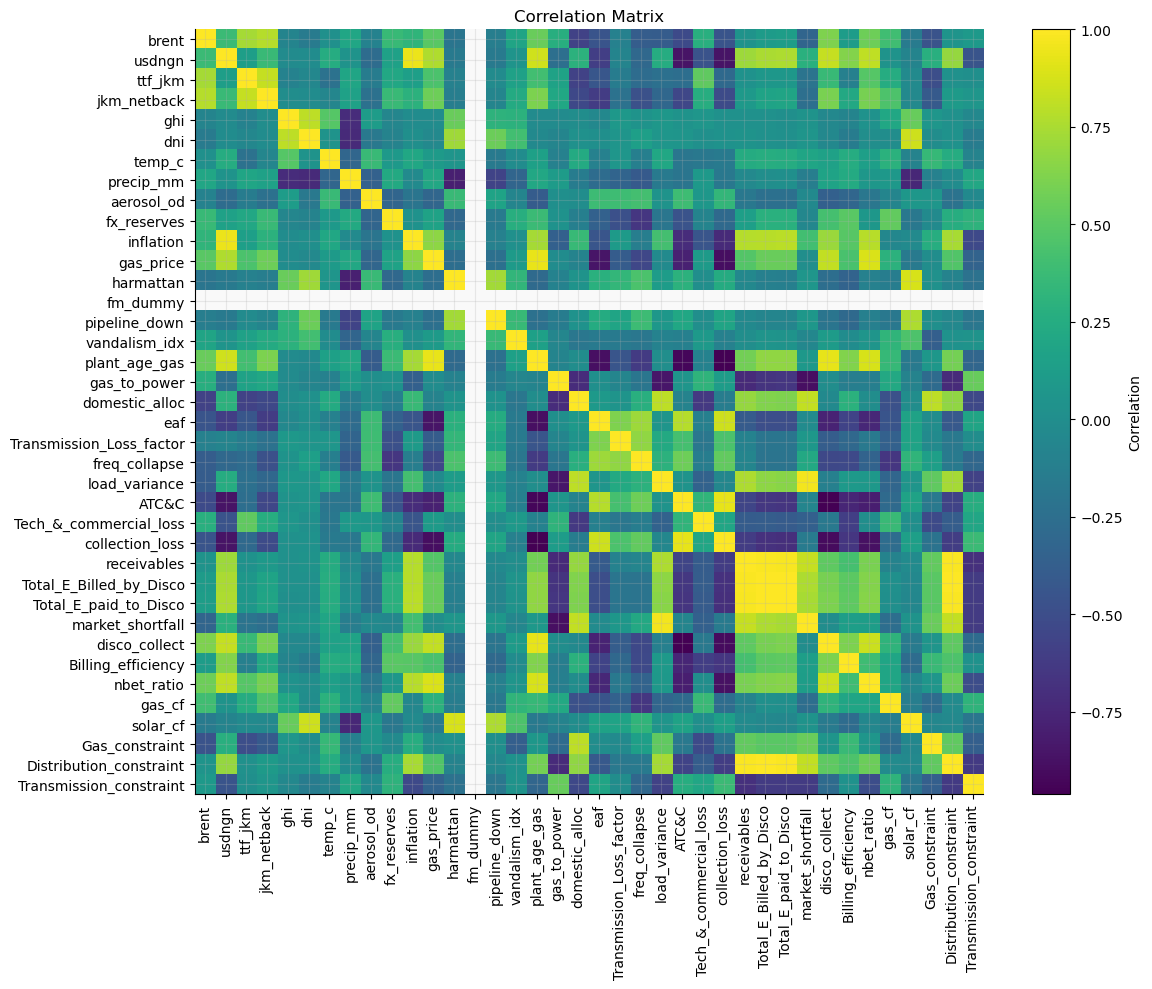

In [7]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 1B — CORRELATION DIAGNOSTICS
# Multicollinearity screening before econometric modelling
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Numeric variables only
num_df = df.select_dtypes(include=[np.number])

# Pearson correlation matrix
corr_matrix = num_df.corr(method='pearson')

# Save full matrix
corr_matrix.to_csv('correlation_matrix.csv')

print("=" * 80)
print("CORRELATION MATRIX SAVED")
print("=" * 80)

print(f"Variables analysed: {corr_matrix.shape[0]}")
print("Saved: correlation_matrix.csv")

# ------------------------------------------------------------
# High-correlation pairs
# ------------------------------------------------------------

threshold = 0.70

high_corr = []

for i in range(len(corr_matrix.columns)):

    for j in range(i+1, len(corr_matrix.columns)):

        corr_val = corr_matrix.iloc[i, j]

        if abs(corr_val) >= threshold:

            high_corr.append([
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_val
            ])

high_corr_df = pd.DataFrame(
    high_corr,
    columns=['Variable_1', 'Variable_2', 'Correlation']
)

high_corr_df = high_corr_df.sort_values(
    by='Correlation',
    key=lambda s: abs(s),
    ascending=False
)

print("\n" + "="*80)
print(f"HIGH CORRELATIONS (|ρ| ≥ {threshold})")
print("="*80)

print(high_corr_df)

high_corr_df.to_csv(
    'high_correlations.csv',
    index=False
)

# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(12,10))

plt.imshow(
    corr_matrix,
    aspect='auto'
)

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title('Correlation Matrix')

plt.tight_layout()

plt.show()

In [8]:
df.columns

Index(['brent', 'usdngn', 'ttf_jkm', 'jkm_netback', 'ghi', 'dni', 'temp_c',
       'precip_mm', 'aerosol_od', 'fx_reserves', 'inflation', 'gas_price',
       'harmattan', 'fm_dummy', 'pipeline_down', 'vandalism_idx',
       'plant_age_gas', 'gas_to_power', 'domestic_alloc', 'eaf',
       'Transmission_Loss_factor', 'freq_collapse', 'load_variance', 'ATC&C',
       'Tech_&_commercial_loss', 'collection_loss', 'receivables',
       'Total_E_Billed_by_Disco', 'Total_E_paid_to_Disco', 'market_shortfall',
       'disco_collect', 'Billing_efficiency', 'nbet_ratio', 'gas_cf',
       'solar_cf', 'Gas_constraint', 'Distribution_constraint',
       'Transmission_constraint'],
      dtype='str')

In [9]:
# ============================================================
# VARIANCE INFLATION FACTOR (VIF) DIAGNOSTICS
# ===========================================================
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


def compute_vif(df, variables, model_name):

    X = df[variables].copy()

    # remove rows with missing values
    X = X.dropna()

    # add intercept
    X = add_constant(X)

    vif_df = pd.DataFrame()

    vif_df["Variable"] = X.columns

    vif_df["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    print("\n" + "="*70)
    print(model_name)
    print("="*70)

    print(
        vif_df
        .sort_values("VIF", ascending=False)
        .round(2)
        .to_string(index=False)
    )

    return vif_df


# ============================================================
# GAS PRICE MODEL
# ============================================================

gas_price_vars = [
    "usdngn",
    "brent",
    "ttf_jkm",
    "jkm_netback",
    "fx_reserves"
]

compute_vif(
    df,
    gas_price_vars,
    "GAS PRICE MODEL"
)

# ===========================================================
# Receivables
# ===========================================================

receivables_vars = [
    "Total_E_Billed_by_Disco",
    "disco_collect",
    "nbet_ratio",
    "gas_cf"
]

compute_vif(
    df,
    receivables_vars, 
    "RECEIVABLES MODEL"
)


# ============================================================
# GAS CAPACITY FACTOR MODEL
# ============================================================

gas_cf_vars = [
    "eaf",
    "domestic_alloc",
    "gas_to_power",
    "pipeline_down",
    "vandalism_idx",
    "freq_collapse"
]

compute_vif(
    df,
    gas_cf_vars,
    "GAS CF MODEL"
)

# ============================================================
# EAF
# ============================================================

eaf_vars = [
    "gas_to_power",
    "vandalism_idx",
    "pipeline_down",
    "plant_age_gas",
    "freq_collapse"
]

compute_vif(
    df,
    eaf_vars,
    "EAF MODEL"
)

# ============================================================
# SOLAR CAPACITY FACTOR MODEL
# ============================================================

solar_cf_vars = [
    "dni",
    "harmattan",
    "precip_mm",
    "aerosol_od",
    "temp_c"
]

compute_vif(
    df,
    solar_cf_vars,
    "SOLAR CF MODEL"
)


GAS PRICE MODEL
   Variable   VIF
      const 55.65
jkm_netback  4.88
    ttf_jkm  4.20
      brent  3.09
     usdngn  1.39
fx_reserves  1.24

RECEIVABLES MODEL
               Variable    VIF
                  const 263.06
          disco_collect   3.87
             nbet_ratio   3.78
Total_E_Billed_by_Disco   1.78
                 gas_cf   1.17

GAS CF MODEL
      Variable     VIF
         const 5429.99
 freq_collapse    2.61
domestic_alloc    2.31
  gas_to_power    2.25
           eaf    2.12
 pipeline_down    1.52
 vandalism_idx    1.43

EAF MODEL
     Variable     VIF
        const 3426.91
freq_collapse    2.14
plant_age_gas    1.74
pipeline_down    1.52
vandalism_idx    1.34
 gas_to_power    1.12

SOLAR CF MODEL
  Variable    VIF
     const 398.46
       dni   5.94
 harmattan   5.05
 precip_mm   4.59
aerosol_od   3.24
    temp_c   1.47


,Variable,VIF
0,const,398.458512
1,dni,5.943443
2,harmattan,5.046224
3,precip_mm,4.586546
4,aerosol_od,3.236329
5,temp_c,1.465773


---
## Cell 2 — Stationarity Testing (ADF + KPSS)

In [10]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 2 — STATIONARITY DIAGNOSTICS
# ADF + KPSS
# ═══════════════════════════════════════════════════════════════════════

from statsmodels.tsa.stattools import adfuller, kpss
df["ln_receivables"] = np.log(df["receivables"])
stationarity_vars = {

    # GAS PRICE MODEL
    'gas_price'             : df['gas_price'],
    'brent'                 : df['brent'],
    'usdngn'                : df['usdngn'],
    'ttf_jkm'               : df['ttf_jkm'],
    'fx_reserves'           : df['fx_reserves'],
    'jkm_netback'           : df['jkm_netback'],

    # RECEIVABLES MODEL
    'ln_receivables'        : df['ln_receivables'],
    'nbet_ratio'            : df['nbet_ratio'],
    'disco_collect'         : df['disco_collect'],
    'gas_cf'                : df['gas_cf'],
    
    # EAF MODEL
    'eaf'                   : df['eaf'],
    'pipeline_down'         : df['pipeline_down'],
    'vandalism_idx'         : df['vandalism_idx'],
    'gas_to_power'          : df['gas_to_power'],
    'plant_age_gas'         : df['plant_age_gas'],
    'freq_collapse'         : df['freq_collapse'],

     # GAS CF MODEL
    'gas_cf'                : df['gas_cf'],
    'eaf'                   : df['eaf'],
    'pipeline_down'         : df['pipeline_down'],
    'vandalism_idx'         : df['vandalism_idx'],
    'freq_collapse'         : df['freq_collapse'],    
    'domestic_alloc'        : df['domestic_alloc'],

    # SOLAR CF MODEL
    'solar_cf'              : df['solar_cf'],
    'dni'                   : df['dni'],
    'precip_mm'             : df['precip_mm'],
    'harmattan'             : df['harmattan'],
    'aerosol_od'            : df['aerosol_od'],
    'temp_c'                : df['temp_c']
}

results = []

for name, series in stationarity_vars.items():

    s = pd.Series(series).dropna()

    try:

        adf_p = adfuller(
            s,
            autolag='AIC'
        )[1]

        kpss_p = kpss(
            s,
            regression='ct',
            nlags='auto'
        )[1]

        if adf_p < 0.05 and kpss_p > 0.05:
            verdict = 'I(0)'
            action = 'LEVEL'

        elif adf_p > 0.05 and kpss_p < 0.05:
            verdict = 'I(1)'
            action = 'DIFFERENCE'

        else:
            verdict = 'Ambiguous'
            action = 'CHECK'

        results.append([
            name,
            round(adf_p,4),
            round(kpss_p,4),
            verdict,
            action
        ])

    except Exception as ex:

        results.append([
            name,
            np.nan,
            np.nan,
            f'Error: {ex}'
        ])

stationarity_results = pd.DataFrame(
    results,
    columns=[
        'Variable',
        'ADF_p',
        'KPSS_p',
        'Conclusion',
        'Action'
    ]
)
print("\nSUMMARY")
print(
    stationarity_results["Conclusion"]
    .value_counts()
)
print(stationarity_results)

stationarity_results.to_csv(
    'stationarity_results.csv',
    index=False
)

C:\Users\pc\AppData\Local\Temp\ipykernel_27088\1958270285.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(
C:\Users\pc\AppData\Local\Temp\ipykernel_27088\1958270285.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(
C:\Users\pc\AppData\Local\Temp\ipykernel_27088\1958270285.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(
C:\Users\pc\AppData\Local\Temp\ipykernel_27088\1958270285.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(
C:\U


SUMMARY
Conclusion
I(1)         11
Ambiguous    11
I(0)          1
Name: count, dtype: int64
          Variable   ADF_p  KPSS_p Conclusion      Action
0        gas_price  0.8509  0.0181       I(1)  DIFFERENCE
1            brent  0.1781  0.1000  Ambiguous       CHECK
2           usdngn  0.8029  0.0100       I(1)  DIFFERENCE
3          ttf_jkm  0.0743  0.0810  Ambiguous       CHECK
4      fx_reserves  0.3363  0.0100       I(1)  DIFFERENCE
5      jkm_netback  0.2136  0.1000  Ambiguous       CHECK
6   ln_receivables  0.9739  0.0100       I(1)  DIFFERENCE
7       nbet_ratio  0.8554  0.0100       I(1)  DIFFERENCE
8    disco_collect  0.8986  0.0943  Ambiguous       CHECK
9           gas_cf  0.1709  0.0100       I(1)  DIFFERENCE
10             eaf  0.5124  0.0100       I(1)  DIFFERENCE
11   pipeline_down  0.1540  0.1000  Ambiguous       CHECK
12   vandalism_idx  0.0000  0.1000       I(0)       LEVEL
13    gas_to_power  0.6805  0.0100       I(1)  DIFFERENCE
14   plant_age_gas  0.9585  0.0100  

C:\Users\pc\AppData\Local\Temp\ipykernel_27088\1958270285.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(
C:\Users\pc\AppData\Local\Temp\ipykernel_27088\1958270285.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(
C:\Users\pc\AppData\Local\Temp\ipykernel_27088\1958270285.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(
C:\Users\pc\AppData\Local\Temp\ipykernel_27088\1958270285.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(
C:\U

CORRELATION MATRIX SAVED
Variables analysed: 39
Saved: correlation_matrix.csv

HIGH CORRELATIONS (|ρ| ≥ 0.7)
                 Variable_1               Variable_2  Correlation
72  Total_E_Billed_by_Disco    Total_E_paid_to_Disco     0.998682
74  Total_E_Billed_by_Disco  Distribution_constraint     0.994050
77    Total_E_paid_to_Disco  Distribution_constraint     0.990634
70              receivables  Distribution_constraint     0.989732
67              receivables  Total_E_Billed_by_Disco     0.985426
..                      ...                      ...          ...
15                      ghi                precip_mm    -0.712727
53                      eaf            freq_collapse     0.710852
45             gas_to_power           domestic_alloc    -0.710411
80         market_shortfall           ln_receivables     0.704773
27                inflation            disco_collect     0.702976

[85 rows x 3 columns]


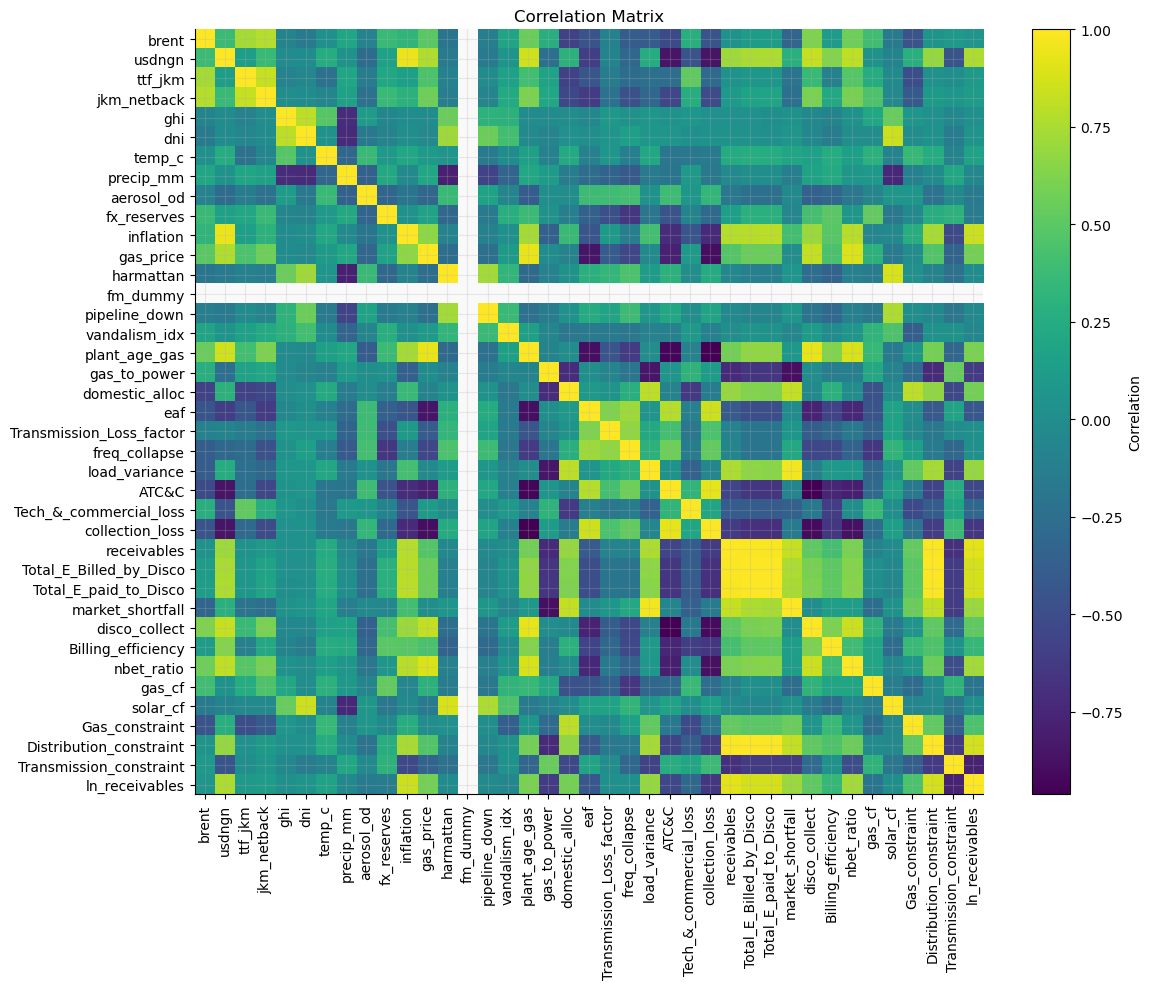

In [11]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 1B — CORRELATION DIAGNOSTICS
# Multicollinearity screening before econometric modelling
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Numeric variables only
num_df = df.select_dtypes(include=[np.number])

# Pearson correlation matrix
corr_matrix = num_df.corr(method='pearson')

# Save full matrix
corr_matrix.to_csv('correlation_matrix.csv')

print("=" * 80)
print("CORRELATION MATRIX SAVED")
print("=" * 80)

print(f"Variables analysed: {corr_matrix.shape[0]}")
print("Saved: correlation_matrix.csv")

# ------------------------------------------------------------
# High-correlation pairs
# ------------------------------------------------------------

threshold = 0.70

high_corr = []

for i in range(len(corr_matrix.columns)):

    for j in range(i+1, len(corr_matrix.columns)):

        corr_val = corr_matrix.iloc[i, j]

        if abs(corr_val) >= threshold:

            high_corr.append([
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_val
            ])

high_corr_df = pd.DataFrame(
    high_corr,
    columns=['Variable_1', 'Variable_2', 'Correlation']
)

high_corr_df = high_corr_df.sort_values(
    by='Correlation',
    key=lambda s: abs(s),
    ascending=False
)

print("\n" + "="*80)
print(f"HIGH CORRELATIONS (|ρ| ≥ {threshold})")
print("="*80)

print(high_corr_df)

high_corr_df.to_csv(
    'high_correlations.csv',
    index=False
)

# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(12,10))

plt.imshow(
    corr_matrix,
    aspect='auto'
)

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title('Correlation Matrix')

plt.tight_layout()

plt.show()

In [12]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 2B — RESOLVE AMBIGUOUS STATIONARITY RESULTS
# KPSS (LEVEL STATIONARITY)
# ═══════════════════════════════════════════════════════════════════════

from statsmodels.tsa.stattools import adfuller, kpss

ambiguous_vars = stationarity_results.loc[
    stationarity_results["Conclusion"] == "Ambiguous",
    "Variable"
].tolist()

results_2b = []

for var in ambiguous_vars:

    s = df[var].dropna()

    try:

        adf_p = adfuller(
            s,
            autolag="AIC"
        )[1]

        kpss_p = kpss(
            s,
            regression="c",
            nlags="auto"
        )[1]

        if adf_p < 0.05 and kpss_p > 0.05:

            verdict = "I(0)"
            action = "LEVEL"

        elif adf_p > 0.05 and kpss_p < 0.05:

            verdict = "I(1)"
            action = "DIFFERENCE"

        else:

            verdict = "Still Ambiguous"
            action = "VISUAL_CHECK"

        results_2b.append([
            var,
            round(adf_p, 4),
            round(kpss_p, 4),
            verdict,
            action
        ])

    except Exception as ex:

        results_2b.append([
            var,
            np.nan,
            np.nan,
            f"Error: {ex}",
            "CHECK"
        ])

cell2b_results = pd.DataFrame(
    results_2b,
    columns=[
        "Variable",
        "ADF_p",
        "KPSS_c_p",
        "Conclusion",
        "Action"
    ]
)

print("\nCELL 2B RESULTS")
print(cell2b_results)

print("\nSUMMARY")
print(cell2b_results["Conclusion"].value_counts())

cell2b_results.to_csv(
    "stationarity_results_cell2b.csv",
    index=False
)


CELL 2B RESULTS
         Variable   ADF_p  KPSS_c_p       Conclusion        Action
0           brent  0.1781    0.0100             I(1)    DIFFERENCE
1         ttf_jkm  0.0743    0.0333             I(1)    DIFFERENCE
2     jkm_netback  0.2136    0.0100             I(1)    DIFFERENCE
3   disco_collect  0.8986    0.0100             I(1)    DIFFERENCE
4   pipeline_down  0.1540    0.0405             I(1)    DIFFERENCE
5        solar_cf  0.0726    0.1000  Still Ambiguous  VISUAL_CHECK
6             dni  0.1554    0.1000  Still Ambiguous  VISUAL_CHECK
7       precip_mm  0.2507    0.0750  Still Ambiguous  VISUAL_CHECK
8       harmattan  0.0701    0.0373             I(1)    DIFFERENCE
9      aerosol_od  0.5959    0.0100             I(1)    DIFFERENCE
10         temp_c  0.4544    0.1000  Still Ambiguous  VISUAL_CHECK

SUMMARY
Conclusion
I(1)               7
Still Ambiguous    4
Name: count, dtype: int64


C:\Users\pc\AppData\Local\Temp\ipykernel_27088\3623046122.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(
C:\Users\pc\AppData\Local\Temp\ipykernel_27088\3623046122.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(
C:\Users\pc\AppData\Local\Temp\ipykernel_27088\3623046122.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(
C:\Users\pc\AppData\Local\Temp\ipykernel_27088\3623046122.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(
C:\U

---
# PART 2 MODELS

## Cell 3 — GAS PRICE
ARDL and Short-Run Differenced Regression models are used here as they both try to answer different questions about the gas Price model.
With ARDL we'll be testing if the Gas Price have a dynamic relationship with the selected Gas Price Variables over time (Cointegration). That is, Current effects + lagged effects + long-run equilibrium.
Short-un Differenced Regression test is the month-to-month changes in these variables explain month-to-month changes in gas price. Purely a short-run relationship check.

In [13]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 3 — ARDL BOUNDS TEST (GAS PRICE MODEL)
# FIXED ECONOMIC SPECIFICATION
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd

from statsmodels.tsa.ardl import ARDL
from statsmodels.tsa.ardl import UECM

# --------------------------------------------------
# DATA
# --------------------------------------------------

gas_ardl_df = df[[
    "gas_price",
    "usdngn",
    "brent",
    "ttf_jkm",
    "jkm_netback",
    "fx_reserves"
]].dropna()

# --------------------------------------------------
# LOG TRANSFORMS
# --------------------------------------------------

gas_ardl_df["ln_gas_price"] = np.log(gas_ardl_df["gas_price"])

gas_ardl_df["ln_usdngn"] = np.log(
    np.clip(gas_ardl_df["usdngn"], 1e-6, None)
)

gas_ardl_df["ln_brent"] = np.log(
    np.clip(gas_ardl_df["brent"], 1e-6, None)
)

gas_ardl_df["ln_fx"] = np.log(
    np.clip(gas_ardl_df["fx_reserves"], 1e-6, None)
)

# --------------------------------------------------
# DEPENDENT VARIABLE
# --------------------------------------------------

y = gas_ardl_df["ln_gas_price"]

# --------------------------------------------------
# EXPLANATORY VARIABLES
# --------------------------------------------------

X = gas_ardl_df[
    [
        "ln_usdngn",
        "ln_brent",
        "ttf_jkm",
        "jkm_netback",
        "ln_fx"
    ]
]

# --------------------------------------------------
# FIXED ARDL(1,1,1,1,1,1)
# --------------------------------------------------

gas_ardl_model = ARDL(
    endog=y,
    lags=1,
    exog=X,
    order=1,
    trend="c"
)

gas_ardl_res = gas_ardl_model.fit()

print("=" * 70)
print("GAS PRICE ARDL RESULTS")
print("=" * 70)

print(gas_ardl_res.summary())

# --------------------------------------------------
# UECM REPRESENTATION
# --------------------------------------------------

gas_uecm = UECM.from_ardl(gas_ardl_model)

gas_uecm_res = gas_uecm.fit()

print("\n")
print("=" * 70)
print("UECM RESULTS")
print("=" * 70)

print(gas_uecm_res.summary())

# --------------------------------------------------
# BOUNDS TEST
# --------------------------------------------------

gas_bounds = gas_uecm_res.bounds_test(case=3)

print("\n")
print("=" * 70)
print("BOUNDS TEST")
print("=" * 70)

print(gas_bounds)

print("\nF-STATISTIC:")
print(gas_bounds.stat)

# --------------------------------------------------
# INTERPRETATION
# --------------------------------------------------

print("\n")
print("=" * 70)
print("INTERPRETATION")
print("=" * 70)

print("Null Hypothesis: No Cointegration")

if gas_bounds.stat > 5:
    print("\nStrong evidence of cointegration.")

elif gas_bounds.stat > 3:
    print("\nPossible cointegration. Check critical values.")

else:
    print("\nLittle evidence of cointegration.")

# --------------------------------------------------
# ERROR CORRECTION TERM
# --------------------------------------------------

if "ci_summary" in dir(gas_uecm_res):

    print("\n")
    print("=" * 70)
    print("LONG-RUN RELATIONSHIP")
    print("=" * 70)

    print(gas_uecm_res.ci_summary())

GAS PRICE ARDL RESULTS
                                ARDL Model Results                                
Dep. Variable:               ln_gas_price   No. Observations:                  132
Model:             ARDL(1, 1, 1, 1, 1, 1)   Log Likelihood                 396.235
Method:                   Conditional MLE   S.D. of innovations              0.012
Date:                    Tue, 09 Jun 2026   AIC                           -766.470
Time:                            18:37:33   BIC                           -729.093
Sample:                        02-01-2015   HQIC                          -751.282
                             - 12-01-2025                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0298      0.035      0.846      0.399      -0.040       0.099
ln_gas_price.L1     1.0208      0.028     36.991      0.000  

The ARDL shows (F-statistics = 0.809, upper p-value = 0.976) that there is no cointegration. And according to the AIC selection, only the 'brent' price has a statistical significance to the Gas price (judging by p-values of both current and lagged).

In [14]:
# ══════════════════════════════════════════════════════════════════════
# CELL 4 — GAS PRICE MODEL
# SHORT-RUN DIFFERENCED REGRESSION
# ══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import statsmodels.api as sm

# --------------------------------------------------
# BUILD REGRESSION DATASET
# --------------------------------------------------

gp = df[
    [
        "gas_price",
        "usdngn",
        "brent",
        "ttf_jkm",
        "jkm_netback",
        "fx_reserves"
    ]
].copy()

# --------------------------------------------------
# LOG TRANSFORMS
# --------------------------------------------------

gp["ln_gas_price"] = np.log(
    np.clip(gp["gas_price"], 1e-6, None)
)

gp["ln_usdngn"] = np.log(
    np.clip(gp["usdngn"], 1e-6, None)
)

gp["ln_brent"] = np.log(
    np.clip(gp["brent"], 1e-6, None)
)

gp["ln_fx"] = np.log(
    np.clip(gp["fx_reserves"], 1e-6, None)
)

# --------------------------------------------------
# FIRST DIFFERENCES
# --------------------------------------------------

gp["d_ln_gas_price"] = gp["ln_gas_price"].diff()

gp["d_ln_usdngn"] = gp["ln_usdngn"].diff()

gp["d_ln_brent"] = gp["ln_brent"].diff()

gp["d_ln_fx"] = gp["ln_fx"].diff()

gp["d_ttf_jkm"] = gp["ttf_jkm"].diff()

gp["d_jkm_netback"] = gp["jkm_netback"].diff()

gp = gp.dropna()

# --------------------------------------------------
# DEPENDENT VARIABLE
# --------------------------------------------------

y = gp["d_ln_gas_price"]

# --------------------------------------------------
# EXPLANATORY VARIABLES
# --------------------------------------------------

X = gp[
    [
        "d_ln_usdngn",
        "d_ln_brent",
        "d_ttf_jkm",
        "d_jkm_netback",
        "d_ln_fx"
    ]
]

X = sm.add_constant(X)

# --------------------------------------------------
# OLS + NEWEY-WEST HAC
# --------------------------------------------------

gas_model = sm.OLS(y, X)

gas_results = gas_model.fit(
    cov_type="HAC",
    cov_kwds={"maxlags":4}
)

# --------------------------------------------------
# OUTPUT
# --------------------------------------------------

print("=" * 80)
print("GAS PRICE MODEL")
print("SHORT-RUN DIFFERENCED REGRESSION")
print("=" * 80)

print(gas_results.summary())

# --------------------------------------------------
# DIAGNOSTICS
# --------------------------------------------------

print("\n")
print("=" * 80)
print("KEY METRICS")
print("=" * 80)

print(f"Observations : {int(gas_results.nobs)}")
print(f"R²           : {gas_results.rsquared:.4f}")
print(f"Adj. R²      : {gas_results.rsquared_adj:.4f}")
print(f"AIC          : {gas_results.aic:.4f}")
print(f"BIC          : {gas_results.bic:.4f}")

# --------------------------------------------------
# ECONOMIC INTERPRETATION TABLE
# --------------------------------------------------

gas_coef_table = pd.DataFrame({
    "Coefficient": gas_results.params,
    "Std_Error": gas_results.bse,
    "t_stat": gas_results.tvalues,
    "p_value": gas_results.pvalues
})

print("\n")
print("=" * 80)
print("COEFFICIENTS")
print("=" * 80)

print(gas_coef_table.round(4))

GAS PRICE MODEL
SHORT-RUN DIFFERENCED REGRESSION
                            OLS Regression Results                            
Dep. Variable:         d_ln_gas_price   R-squared:                       0.293
Model:                            OLS   Adj. R-squared:                  0.265
Method:                 Least Squares   F-statistic:                    0.8482
Date:                Tue, 09 Jun 2026   Prob (F-statistic):              0.518
Time:                        18:37:35   Log-Likelihood:                 393.62
No. Observations:                 131   AIC:                            -775.2
Df Residuals:                     125   BIC:                            -758.0
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

The short-run Regression analysis says that none of the candidate variables significantly explains changes in gas price. This suggests that Nigerian Domestic Gas Price is not primarily driven by Brent, FX, LNG Prices, Netback Prices and Reserves over the sample period.

In [15]:
# ==========================================================
# LOCK FINAL GAS PRICE MODEL
# ==========================================================

gas_final = gas_results

print("Gas Price model locked")

Gas Price model locked


Bounds testing found no evidence of cointegration between domestic gas prices and the selected market variables. Furthermore, short-run differenced regressions showed no statistically significant effects from changes in Brent, exchange rates, LNG benchmarks, netback prices, or foreign reserves. This suggests that domestic gas prices in Nigeria are influenced more by policy, contractual arrangements, and administrative mechanisms than by market fundamentals.

---
## EAF MODEL


EAF DESCRIPTIVE STATISTICS
Mean : 45.8182
Min  : 27.4900
Max  : 64.7000
Std  : 13.0170

Full Summary
count    132.000000
mean      45.818217
std       13.016966
min       27.490000
25%       33.280000
50%       43.050000
75%       61.645713
max       64.700000
Name: eaf, dtype: float64


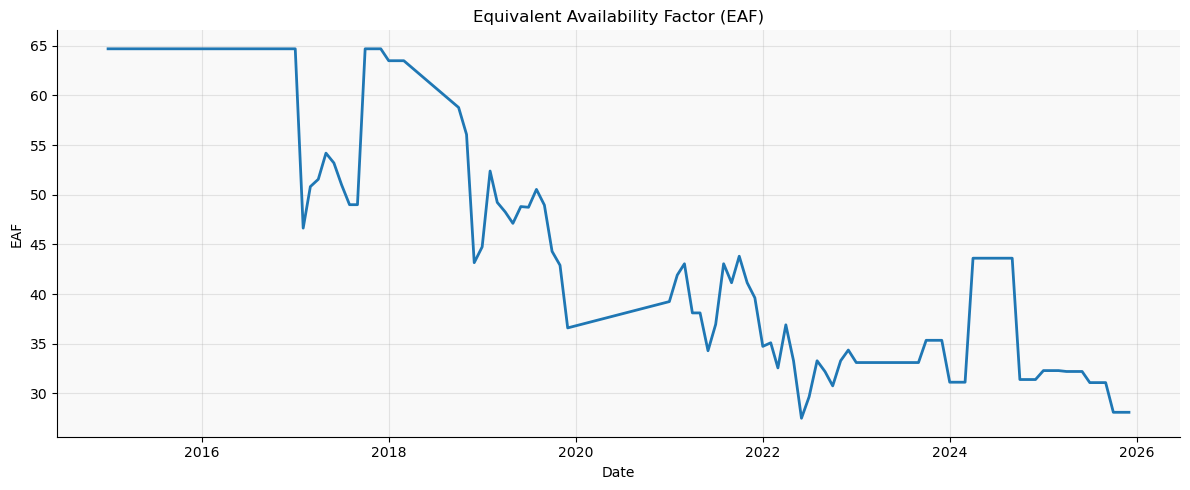


EAF CORRELATION MATRIX
                 eaf  pipeline_down  vandalism_idx  plant_age_gas  \
eaf            1.000          0.245         -0.159         -0.880   
pipeline_down  0.245          1.000          0.360         -0.228   
vandalism_idx -0.159          0.360          1.000          0.150   
plant_age_gas -0.880         -0.228          0.150          1.000   
gas_to_power   0.014         -0.134         -0.058         -0.074   
freq_collapse  0.711          0.384         -0.184         -0.622   

               gas_to_power  freq_collapse  
eaf                   0.014          0.711  
pipeline_down        -0.134          0.384  
vandalism_idx        -0.058         -0.184  
plant_age_gas        -0.074         -0.622  
gas_to_power          1.000         -0.192  
freq_collapse        -0.192          1.000  


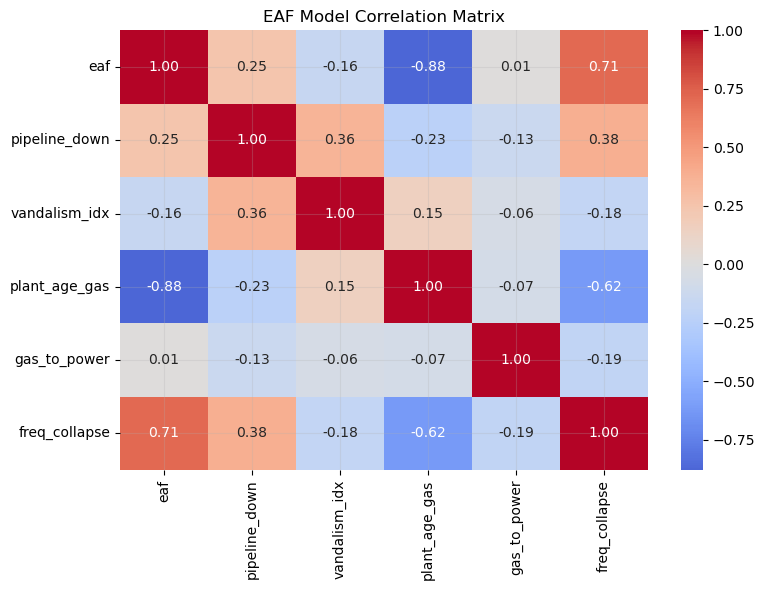

In [16]:
# ═══════════════════════════════════════════════════════════════════════
# EAF DIAGNOSTICS
# Descriptive Statistics + Time Series Plot + Correlation Matrix
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------
# VARIABLES
# -------------------------------------------------------------

eaf_vars = [
    'eaf',
    'pipeline_down',
    'vandalism_idx',
    'plant_age_gas',
    'gas_to_power',
    'freq_collapse'
]

eaf_df = df[eaf_vars].copy()

# -------------------------------------------------------------
# 1. EAF DESCRIPTIVE STATISTICS
# -------------------------------------------------------------

print("\n" + "="*70)
print("EAF DESCRIPTIVE STATISTICS")
print("="*70)

print(f"Mean : {eaf_df['eaf'].mean():.4f}")
print(f"Min  : {eaf_df['eaf'].min():.4f}")
print(f"Max  : {eaf_df['eaf'].max():.4f}")
print(f"Std  : {eaf_df['eaf'].std():.4f}")

print("\nFull Summary")
print(eaf_df['eaf'].describe())

# -------------------------------------------------------------
# 2. EAF TIME SERIES PLOT
# -------------------------------------------------------------

plt.figure(figsize=(12,5))

plt.plot(
    df.index,
    eaf_df['eaf'],
    linewidth=2
)

plt.title("Equivalent Availability Factor (EAF)")
plt.xlabel("Date")
plt.ylabel("EAF")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 3. EAF CORRELATION MATRIX
# -------------------------------------------------------------

eaf_corr_matrix = eaf_df.corr()

print("\n" + "="*70)
print("EAF CORRELATION MATRIX")
print("="*70)

print(eaf_corr_matrix.round(3))

plt.figure(figsize=(8,6))

sns.heatmap(
    eaf_corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title("EAF Model Correlation Matrix")

plt.tight_layout()
plt.show()

In [17]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 6 — EAF ARDL LAG SELECTION
# ═══════════════════════════════════════════════════════════════════════

from statsmodels.tsa.ardl import ardl_select_order

# -------------------------------------------------------------
# DEPENDENT VARIABLE
# -------------------------------------------------------------

y = df["eaf"]

# -------------------------------------------------------------
# EXPLANATORY VARIABLES
# -------------------------------------------------------------

X = df[
    [
        "pipeline_down",
        "vandalism_idx",
        "plant_age_gas",
        "gas_to_power",
        "freq_collapse"
    ]
]

# -------------------------------------------------------------
# AUTOMATIC ARDL ORDER SELECTION
# -------------------------------------------------------------

eaf_sel = ardl_select_order(
    endog=y,
    maxlag=4,
    exog=X,
    maxorder=4,
    ic="aic",
    trend="c"
)

print("\n" + "="*70)
print("SELECTED ARDL ORDER")
print("="*70)

print(eaf_sel.model.ardl_order)

# -------------------------------------------------------------
# FIT SELECTED MODEL
# -------------------------------------------------------------

eaf_ardl_model = eaf_sel.model.fit()

print("\n" + "="*70)
print("ARDL SUMMARY")
print("="*70)

print(eaf_ardl_model.summary())


SELECTED ARDL ORDER
(1, 2, 1)

ARDL SUMMARY
                              ARDL Model Results                              
Dep. Variable:                    eaf   No. Observations:                  132
Model:                  ARDL(1, 2, 1)   Log Likelihood                -307.912
Method:               Conditional MLE   S.D. of innovations              2.538
Date:                Tue, 09 Jun 2026   AIC                            631.823
Time:                        18:37:53   BIC                            654.825
Sample:                    03-01-2015   HQIC                           641.170
                         - 12-01-2025                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               16.9521      8.673      1.955      0.053      -0.213      34.117
eaf.L1               0.8184      0.042     19.642      0.000       0

From the Automactic ARDL Selection, variables selected are eaf.L1 (highly persistent), plant_age_gas.L0, plant_age_gas.L1, plant_age_gas.L2, freq_collapse.L0, freq_collapse.L1. The positive sign in Frequeny collapse is counterintuitive, possible reverse causality or ommitted variable effects.
The full EAF ARDL MODEL doesn't perform better than the AIC-selceted specification above, i'll keep the later.

In [18]:
# ═══════════════════════════════════════════════════════════════════════
# Diagnosis
# EAF ARDL (AGE REMOVED, TREND INCLUDED)
# ═══════════════════════════════════════════════════════════════════════
y = df["eaf"]

X = df[
    [
        "pipeline_down",
        "vandalism_idx",
        "gas_to_power",
        "freq_collapse"
    ]
]

eaf_sel2 = ardl_select_order(
    endog=y,
    exog=X,
    maxlag=4,
    maxorder=4,
    ic="aic",
    trend="ct"
)

print("\nSELECTED ORDER")
print(eaf_sel2.model.ardl_order)

print("\nAR LAGS")
print(eaf_sel2.model.ar_lags)

print("\nDL LAGS")
print(eaf_sel2.model.dl_lags)

eaf_model_2 = eaf_sel2.model.fit()

print(eaf_model_2.summary())


SELECTED ORDER
(1, 0, 4)

AR LAGS
[1]

DL LAGS
{'vandalism_idx': [0], 'freq_collapse': [0, 1, 2, 3, 4]}
                              ARDL Model Results                              
Dep. Variable:                    eaf   No. Observations:                  132
Model:                  ARDL(1, 0, 4)   Log Likelihood                -331.678
Method:               Conditional MLE   S.D. of innovations              3.043
Date:                Tue, 09 Jun 2026   AIC                            683.356
Time:                        18:37:56   BIC                            712.108
Sample:                    05-01-2015   HQIC                           695.039
                         - 12-01-2025                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               11.4129      3.293      3.466      0.001       4.894      17.932
trend   

In this alternative selection, only freq_collapse is significant (P-value < 0.05). But the model Quality, represented by AIC is much worse (683) than the previous model (631). so Previous model trumps.

In [19]:
# ==========================================================
# FORCED ECM-COMPATIBLE EAF ARDL
# ==========================================================

from statsmodels.tsa.ardl import ARDL

eaf_theory_ardl = ARDL(
    endog=df["eaf"],
    lags=1,
    exog=df[
        [
            "pipeline_down",
            "vandalism_idx",
            "gas_to_power",
            "freq_collapse"
        ]
    ],
    order=1,
    trend="ct"
).fit()

print(eaf_theory_ardl.summary())

                               ARDL Model Results                              
Dep. Variable:                     eaf   No. Observations:                  132
Model:             ARDL(1, 1, 1, 1, 1)   Log Likelihood                -333.521
Method:                Conditional MLE   S.D. of innovations              3.086
Date:                 Tue, 09 Jun 2026   AIC                            691.042
Time:                         18:37:56   BIC                            725.544
Sample:                     02-01-2015   HQIC                           705.062
                          - 12-01-2025                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                6.4934     16.681      0.389      0.698     -26.534      39.521
trend               -0.0432      0.017     -2.525      0.013      -0.077      -0.009
eaf.L1              

For theory validation, i forced in pipeline_down, vandalism_idx, gas_to_power and freq_collapse To test if the conceptual engineering stroy survives econometric scrutiny. It didn't as all the forced in variable shows not to be significant.

Since ADRL alone cannot tell us whether a long-run relationship exists, Up next, I'll run UECM test, to check if deviations from equilibrium gets corrected.

In [20]:
from statsmodels.tsa.ardl import UECM

eaf_uecm = UECM.from_ardl(eaf_sel.model)

eaf_uecm_res = eaf_uecm.fit()

print(eaf_uecm_res.summary())

                              UECM Model Results                              
Dep. Variable:                  D.eaf   No. Observations:                  132
Model:                  UECM(1, 2, 1)   Log Likelihood                -306.059
Method:               Conditional MLE   S.D. of innovations             47.651
Date:                Tue, 09 Jun 2026   AIC                            628.118
Time:                        18:37:56   BIC                            651.059
Sample:                    03-01-2015   HQIC                           637.440
                         - 12-01-2025                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 16.9521      8.673      1.955      0.053      -0.215      34.119
eaf.L1                -0.1816      0.042     -4.358      0.000      -0.264      -0.099
plant_age_gas.L1    

c:\Users\pc\miniconda3\envs\FE\Lib\site-packages\statsmodels\tsa\ardl\model.py:455: SpecificationWarning: exog contains variables that are missing from the order dictionary.  Missing keys: pipeline_down, gas_to_power, vandalism_idx.
  return _format_order(self.data.orig_exog, order, self._causal)


In [21]:
forced_bt = eaf_uecm_res.bounds_test(case=5)

print(forced_bt)

BoundsTestResult
Stat: 14.99075
Upper P-value: 4.15e-08
Lower P-value: 3.5e-09
Null: No Cointegration
Alternative: Possible Cointegration



c:\Users\pc\miniconda3\envs\FE\Lib\site-packages\statsmodels\tsa\ardl\model.py:455: SpecificationWarning: exog contains variables that are missing from the order dictionary.  Missing keys: pipeline_down, gas_to_power, vandalism_idx.
  return _format_order(self.data.orig_exog, order, self._causal)


The error correction term, eaf.L1 = -0.214 and p=0.000, shows that approximately 18% of disequilibrium is corrected each month. And only freq_collapse.L1 is clearly significant (P=0.000), Pipeline down is borderline.

In [22]:
# ==========================================================
# FINAL EAF MODEL
# ==========================================================

eaf_final_model = eaf_ardl_model

Pipeline downtime, vandalism incidents, and gas-to-power allocation were initially included based on engineering considerations. However, when forced into the ARDL specification, these variables remained statistically insignificant and materially worsened model fit (higher AIC). Consequently, the final EAF specification retained only the statistically supported variables identified through ARDL lag selection.

---
## GAS CF MODEL


GAS CF DESCRIPTIVE STATISTICS
Mean : 27.4057
Min  : 22.8100
Max  : 34.6600
Std  : 3.2706

Full Summary
count    132.000000
mean      27.405734
std        3.270559
min       22.810000
25%       24.980000
50%       27.500000
75%       29.682500
max       34.660000
Name: gas_cf, dtype: float64


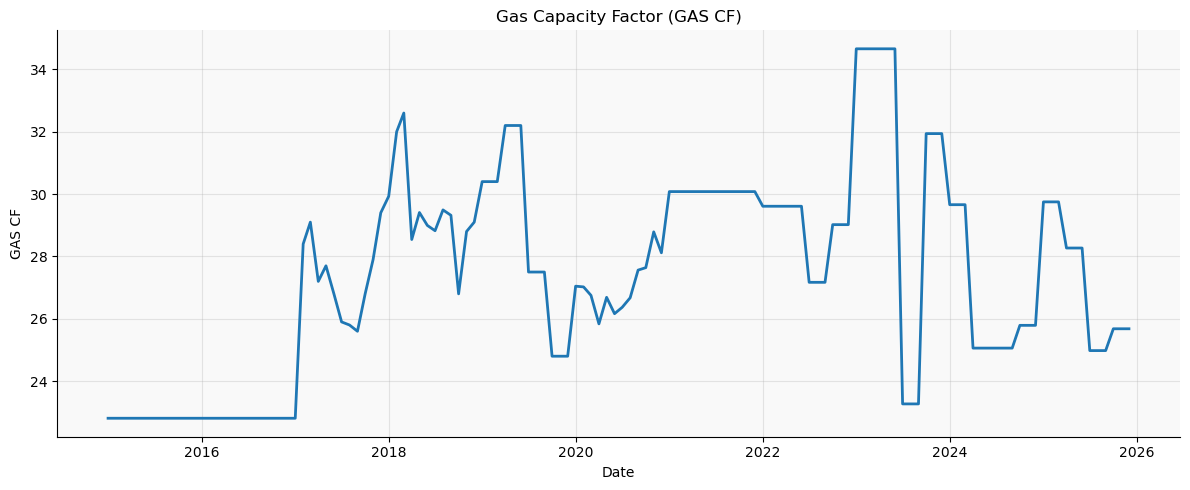


GAS CF CORRELATION MATRIX
                gas_cf    eaf  pipeline_down  vandalism_idx  domestic_alloc  \
gas_cf           1.000 -0.450         -0.174          0.322          -0.476   
eaf             -0.450  1.000          0.245         -0.159           0.103   
pipeline_down   -0.174  0.245          1.000          0.360           0.038   
vandalism_idx    0.322 -0.159          0.360          1.000          -0.185   
domestic_alloc  -0.476  0.103          0.038         -0.185           1.000   
freq_collapse   -0.652  0.711          0.384         -0.184           0.274   

                freq_collapse  
gas_cf                 -0.652  
eaf                     0.711  
pipeline_down           0.384  
vandalism_idx          -0.184  
domestic_alloc          0.274  
freq_collapse           1.000  


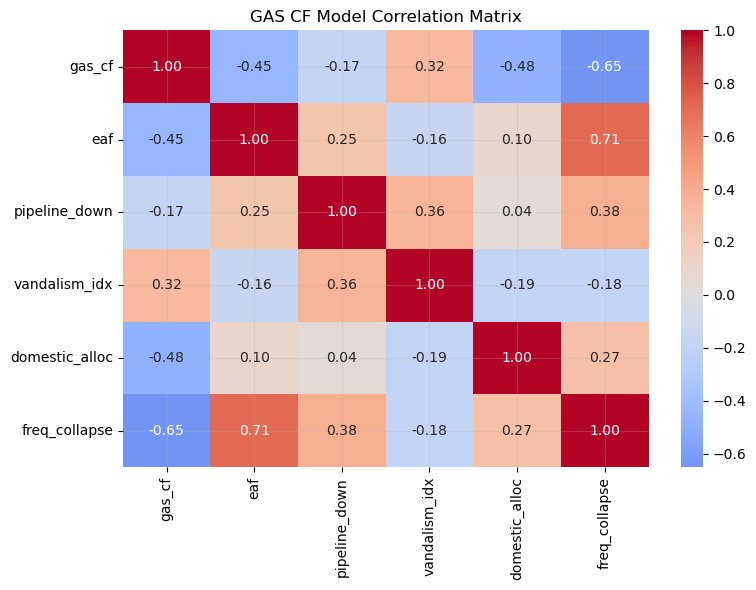

In [23]:
# ═══════════════════════════════════════════════════════════════════════
# GAS CF MODEL DIAGNOSTICS
# Descriptive Statistics + Time Series Plot + Correlation Matrix
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------
# VARIABLES
# -------------------------------------------------------------

gas_cf_vars = [
    'gas_cf',
    'eaf',
    'pipeline_down',
    'vandalism_idx',
    'domestic_alloc',
    'freq_collapse'
]

gas_cf_df = df[gas_cf_vars].copy()

# -------------------------------------------------------------
# 1. GAS CF DESCRIPTIVE STATISTICS
# -------------------------------------------------------------

print("\n" + "="*70)
print("GAS CF DESCRIPTIVE STATISTICS")
print("="*70)

print(f"Mean : {gas_cf_df['gas_cf'].mean():.4f}")
print(f"Min  : {gas_cf_df['gas_cf'].min():.4f}")
print(f"Max  : {gas_cf_df['gas_cf'].max():.4f}")
print(f"Std  : {gas_cf_df['gas_cf'].std():.4f}")

print("\nFull Summary")
print(gas_cf_df['gas_cf'].describe())

# -------------------------------------------------------------
# 2. GAS CF TIME SERIES PLOT
# -------------------------------------------------------------

plt.figure(figsize=(12,5))

plt.plot(
    df.index,
    gas_cf_df['gas_cf'],
    linewidth=2
)

plt.title("Gas Capacity Factor (GAS CF)")
plt.xlabel("Date")
plt.ylabel("GAS CF")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 3. GAS CF CORRELATION MATRIX
# -------------------------------------------------------------

gas_corr_matrix = gas_cf_df.corr()

print("\n" + "="*70)
print("GAS CF CORRELATION MATRIX")
print("="*70)

print(gas_corr_matrix.round(3))

plt.figure(figsize=(8,6))

sns.heatmap(
    gas_corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title("GAS CF Model Correlation Matrix")

plt.tight_layout()
plt.show()

Next, we go through Automatic ARDL Selection for the purpose of determining the best dynamic structure.

In [24]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 6 — GAS CF ARDL LAG SELECTION
# ═══════════════════════════════════════════════════════════════════════

from statsmodels.tsa.ardl import ardl_select_order

# -------------------------------------------------------------
# DEPENDENT VARIABLE
# -------------------------------------------------------------

y = df["gas_cf"]

# -------------------------------------------------------------
# EXPLANATORY VARIABLES
# -------------------------------------------------------------

X = df[
    [
        "eaf",
        "pipeline_down",
        "freq_collapse",
        "domestic_alloc"
    ]
]

# -------------------------------------------------------------
# AUTOMATIC ARDL ORDER SELECTION
# -------------------------------------------------------------

sel_gcf = ardl_select_order(
    endog=y,
    maxlag=4,
    exog=X,
    maxorder=4,
    ic="aic",
    trend="c"
)

print("\n" + "="*70)
print("SELECTED ARDL ORDER")
print("="*70)

print(sel_gcf.model.ardl_order)

print("\nAR LAGS")
print(sel_gcf.model.ar_lags)

print("\nDL LAGS")
print(sel_gcf.model.dl_lags)

# -------------------------------------------------------------
# FIT SELECTED MODEL
# -------------------------------------------------------------

gcf_model = sel_gcf.model.fit()

print("\n" + "="*70)
print("ARDL SUMMARY")
print("="*70)

print(gcf_model.summary())


SELECTED ARDL ORDER
(3, 1, 0, 1)

AR LAGS
[1, 2, 3]

DL LAGS
{'pipeline_down': [0, 1], 'freq_collapse': [0], 'domestic_alloc': [0, 1]}

ARDL SUMMARY
                              ARDL Model Results                              
Dep. Variable:                 gas_cf   No. Observations:                  132
Model:               ARDL(3, 1, 0, 1)   Log Likelihood                -239.680
Method:               Conditional MLE   S.D. of innovations              1.551
Date:                Tue, 09 Jun 2026   AIC                            499.360
Time:                        18:38:00   BIC                            527.958
Sample:                    04-01-2015   HQIC                           510.980
                         - 12-01-2025                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                10.9039      2.406      4

resulting structure is ARDL(3,1,0,1) and Selected variables are: gas_cf, freq_collapse, domestic_alloc, pipeline_down. with gas_cf.L1 being of dominant effect. Basically the current gas capacity factor is heavily influneced by previous gas capacity factor.
Pipeline_down current effect is weak and Lagged effect is borderline significant.
Freq_collapse is a very strong driver.

The optimal ARDL specification selected by AIC included a contemporaneous-only frequency collapse term, preventing direct UECM transformation.

In [25]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

johansen_data = df[
    [
        "gas_cf",
        "pipeline_down",
        "freq_collapse",
        "domestic_alloc"
    ]
].dropna()

jres = coint_johansen(
    johansen_data,
    det_order=0,
    k_ar_diff=1
)

print("Trace Statistics")
print(jres.lr1)

print("\nCritical Values (95%)")
print(jres.cvt[:,1])

Trace Statistics
[103.13793915  48.89815211   7.94752452   0.10612274]

Critical Values (95%)
[47.8545 29.7961 15.4943  3.8415]


Johansen cointegration testing was conducted on the final model variables. The trace statistics exceeded the 95% critical values for the first two ranks, indicating the presence of two cointegrating relationships among Gas CF, Pipeline Down, Frequency Collapse, and Domestic Allocation.

In [26]:
# ==========================================================
# LOCK GAS CF CANDIDATE MODEL
# ==========================================================

gcf_final_model = gcf_model

print(gcf_final_model.summary())

                              ARDL Model Results                              
Dep. Variable:                 gas_cf   No. Observations:                  132
Model:               ARDL(3, 1, 0, 1)   Log Likelihood                -239.680
Method:               Conditional MLE   S.D. of innovations              1.551
Date:                Tue, 09 Jun 2026   AIC                            499.360
Time:                        18:38:00   BIC                            527.958
Sample:                    04-01-2015   HQIC                           510.980
                         - 12-01-2025                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                10.9039      2.406      4.531      0.000       6.140      15.668
gas_cf.L1             0.7704      0.088      8.746      0.000       0.596       0.945
gas_cf.L2            -0.

---
## Receivables Model

In [27]:
df['receivables'].describe()

count    1.320000e+02
mean     2.023376e+11
std      2.306087e+11
min      5.312900e+10
25%      1.172500e+11
50%      1.520000e+11
75%      1.532500e+11
max      9.690000e+11
Name: receivables, dtype: float64

In [28]:
df["ln_receivables"] = np.log(df["receivables"])

In [29]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 3 — RECEIVABLES CORRELATION ANALYSIS
# Pearson + Spearman
# ═══════════════════════════════════════════════════════════════════════

recv_vars = [
    'ln_receivables',
    'nbet_ratio',
    'disco_collect',
    'gas_cf'
]

recv_df = df[recv_vars].copy()

print("="*70)
print("PEARSON CORRELATION")
print("="*70)

pearson_corr = recv_df.corr(method='pearson')
print(pearson_corr)

print("\n")

print("="*70)
print("SPEARMAN CORRELATION")
print("="*70)

spearman_corr = recv_df.corr(method='spearman')
print(spearman_corr)

PEARSON CORRELATION
                ln_receivables  nbet_ratio  disco_collect    gas_cf
ln_receivables        1.000000    0.725261       0.510051 -0.196561
nbet_ratio            0.725261    1.000000       0.841536  0.195200
disco_collect         0.510051    0.841536       1.000000  0.311247
gas_cf               -0.196561    0.195200       0.311247  1.000000


SPEARMAN CORRELATION
                ln_receivables  nbet_ratio  disco_collect    gas_cf
ln_receivables        1.000000    0.727557       0.407304 -0.222995
nbet_ratio            0.727557    1.000000       0.753483  0.077540
disco_collect         0.407304    0.753483       1.000000  0.334655
gas_cf               -0.222995    0.077540       0.334655  1.000000


In [30]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 4A — ARDL LAG SELECTION
# ln_receivables
# ═══════════════════════════════════════════════════════════════════════

from statsmodels.tsa.ardl import ardl_select_order

y = df["ln_receivables"]

X = df[
    [
        "nbet_ratio",
        "disco_collect",
        "gas_cf"
    ]
]

sel_recv = ardl_select_order(
    endog=y,
    exog=X,
    maxlag=4,
    maxorder=4,
    ic="aic",
    trend="c"
)

print("\nSELECTED ORDER")
print(sel_recv.model.ardl_order)

print("\nAR LAGS")
print(sel_recv.model.ar_lags)

print("\nDL LAGS")
print(sel_recv.model.dl_lags)


SELECTED ORDER
(1, 0, 1)

AR LAGS
[1]

DL LAGS
{'nbet_ratio': [0], 'disco_collect': [0, 1]}


In [31]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 4B — ARDL ESTIMATION
# ═══════════════════════════════════════════════════════════════════════

recv_ardl = sel_recv.model.fit()

print("\n" + "="*70)
print("ARDL SUMMARY")
print("="*70)

print(recv_ardl.summary())


ARDL SUMMARY
                              ARDL Model Results                              
Dep. Variable:         ln_receivables   No. Observations:                  132
Model:                  ARDL(1, 0, 1)   Log Likelihood                  66.399
Method:               Conditional MLE   S.D. of innovations              0.146
Date:                Tue, 09 Jun 2026   AIC                           -120.797
Time:                        18:38:01   BIC                           -103.546
Sample:                    02-01-2015   HQIC                          -113.787
                         - 12-01-2025                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.0427      0.772      1.350      0.180      -0.486       2.571
ln_receivables.L1     0.9543      0.028     34.043      0.000       0.899       1.010
nbet_ratio

In [32]:
# ═══════════════════════════════════════════════════════════════
# RECEIVABLES ECM-COMPATIBLE ARDL
# ═══════════════════════════════════════════════════════════════

from statsmodels.tsa.ardl import ARDL

recv_ardl_ecm = ARDL(
    endog=df["ln_receivables"],
    lags=1,
    exog=df[
        [
            "nbet_ratio",
            "disco_collect"
        ]
    ],
    order=1,
    trend="c"
).fit()

print(recv_ardl_ecm.summary())

                              ARDL Model Results                              
Dep. Variable:         ln_receivables   No. Observations:                  132
Model:                  ARDL(1, 1, 1)   Log Likelihood                  66.500
Method:               Conditional MLE   S.D. of innovations              0.146
Date:                Tue, 09 Jun 2026   AIC                           -119.001
Time:                        18:38:01   BIC                            -98.874
Sample:                    02-01-2015   HQIC                          -110.823
                         - 12-01-2025                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.9418      0.808      1.165      0.246      -0.657       2.541
ln_receivables.L1     0.9575      0.029     32.944      0.000       0.900       1.015
nbet_ratio.L0         0.

In [51]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

johansen_recv = df[
    [
        "ln_receivables",
        "nbet_ratio",
        "disco_collect"
    ]
].dropna()

jres = coint_johansen(
    johansen_recv,
    det_order=0,
    k_ar_diff=1
)

print("Trace Statistics")
print(jres.lr1)

print("\nCritical Values (95%)")
print(jres.cvt[:,1])

Trace Statistics
[1.49663816e+01 7.05589936e+00 1.50999674e-03]

Critical Values (95%)
[29.7961 15.4943  3.8415]


There is no evidence of a stable long-run equilibrium relationship among the variables included in this Johansen test. While the ARDL captures dyamic short-run relationships

In [ ]:
recv_final = recv_ardl

---
## Solar CF


SOLAR CF DESCRIPTIVE STATISTICS
Mean : 16.7614
Min  : 12.5000
Max  : 23.0000
Std  : 3.2412

Full Summary
count    132.000000
mean      16.761364
std        3.241234
min       12.500000
25%       13.500000
50%       16.250000
75%       19.000000
max       23.000000
Name: solar_cf, dtype: float64


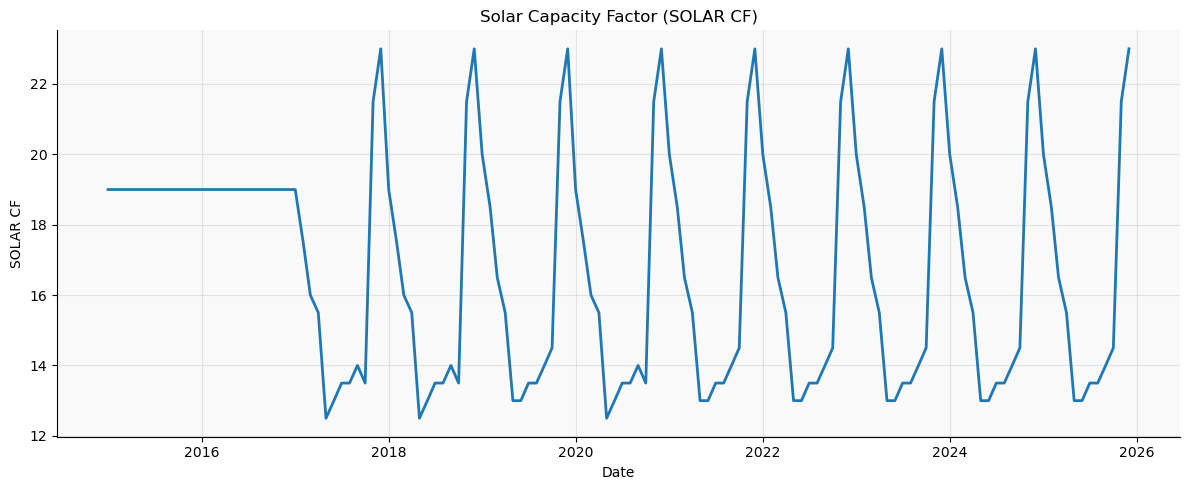

PEARSON CORRELATION
            solar_cf       dni  precip_mm  harmattan  aerosol_od    temp_c
solar_cf    1.000000  0.847770  -0.744785   0.880579    0.076594 -0.083846
dni         0.847770  1.000000  -0.725891   0.717488   -0.168905  0.049323
precip_mm  -0.744785 -0.725891   1.000000  -0.791165   -0.352891 -0.314864
harmattan   0.880579  0.717488  -0.791165   1.000000    0.366327  0.061090
aerosol_od  0.076594 -0.168905  -0.352891   0.366327    1.000000  0.369481
temp_c     -0.083846  0.049323  -0.314864   0.061090    0.369481  1.000000


SPEARMAN CORRELATION
            solar_cf       dni  precip_mm  harmattan  aerosol_od    temp_c
solar_cf    1.000000  0.832646  -0.818978   0.872016    0.121625 -0.043161
dni         0.832646  1.000000  -0.777433   0.757073   -0.039725  0.129485
precip_mm  -0.818978 -0.777433   1.000000  -0.869534   -0.385385 -0.163125
harmattan   0.872016  0.757073  -0.869534   1.000000    0.368096  0.106244
aerosol_od  0.121625 -0.039725  -0.385385   0.368096    1

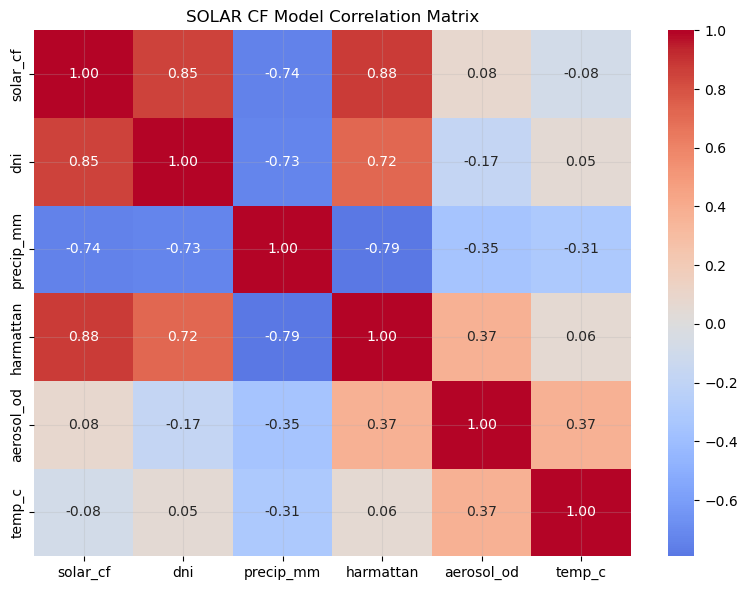

In [36]:
# ═══════════════════════════════════════════════════════════════════════
# SOLAR CF MODEL DIAGNOSTICS
# Descriptive Statistics + Time Series Plot + Correlation Matrix
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------
# VARIABLES
# -------------------------------------------------------------

solar_cf_vars = [
    'solar_cf',
    'dni',
    'precip_mm',
    'harmattan',
    'aerosol_od',
    'temp_c'
]

solar_cf_df = df[solar_cf_vars].copy()

# -------------------------------------------------------------
# 1. SOLAR CF DESCRIPTIVE STATISTICS
# -------------------------------------------------------------

print("\n" + "="*70)
print("SOLAR CF DESCRIPTIVE STATISTICS")
print("="*70)

print(f"Mean : {solar_cf_df['solar_cf'].mean():.4f}")
print(f"Min  : {solar_cf_df['solar_cf'].min():.4f}")
print(f"Max  : {solar_cf_df['solar_cf'].max():.4f}")
print(f"Std  : {solar_cf_df['solar_cf'].std():.4f}")

print("\nFull Summary")
print(solar_cf_df['solar_cf'].describe())

# -------------------------------------------------------------
# 2. SOLAR CF TIME SERIES PLOT
# -------------------------------------------------------------

plt.figure(figsize=(12,5))

plt.plot(
    df.index,
    solar_cf_df['solar_cf'],
    linewidth=2
)

plt.title("Solar Capacity Factor (SOLAR CF)")
plt.xlabel("Date")
plt.ylabel("SOLAR CF")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 3. SOLAR CF CORRELATION MATRIX
# -------------------------------------------------------------
print("="*70)
print("PEARSON CORRELATION")
print("="*70)

pearson_corr = solar_cf_df.corr(method='pearson')
print(pearson_corr)

print("\n")

print("="*70)
print("SPEARMAN CORRELATION")
print("="*70)

spearman_corr = solar_cf_df.corr(method='spearman')
print(spearman_corr)

corr_matrix = solar_cf_df.corr()

print("\n" + "="*70)
print("SOLAR CF CORRELATION MATRIX")
print("="*70)

print(corr_matrix.round(3))

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title("SOLAR CF Model Correlation Matrix")

plt.tight_layout()
plt.show()

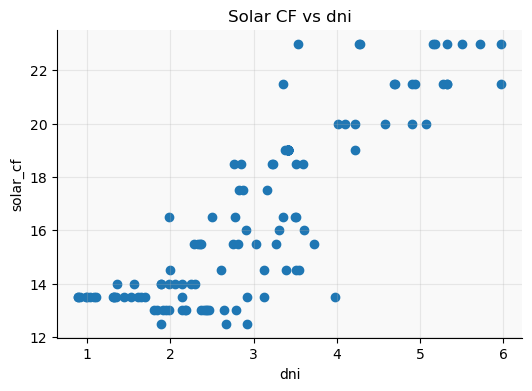

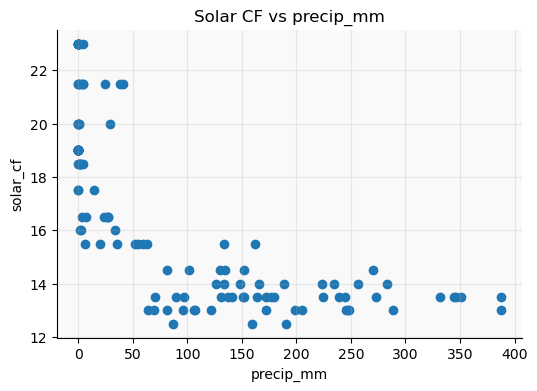

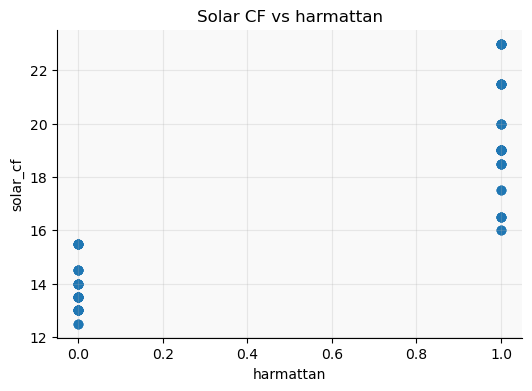

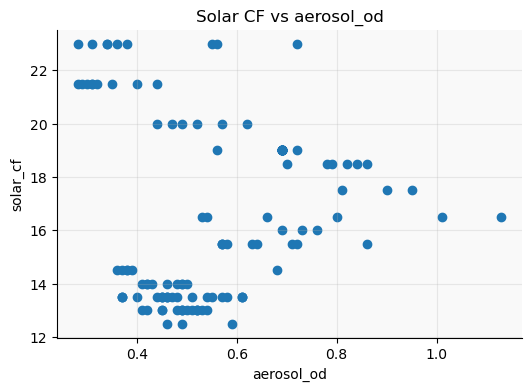

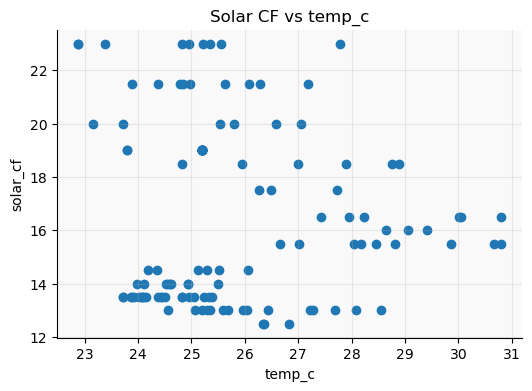

In [37]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 4 — SCATTER PLOTS
# Solar CF vs Drivers
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

solar_vars = [
    'dni',
    'precip_mm',
    'harmattan',
    'aerosol_od',
    'temp_c'
]

for var in solar_vars:

    plt.figure(figsize=(6,4))

    plt.scatter(
        df[var],
        df['solar_cf']
    )

    plt.xlabel(var)
    plt.ylabel('solar_cf')
    plt.title(f'Solar CF vs {var}')

    plt.grid(True)

    plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 4A — ARDL LAG SELECTION
# solar_cf
# ═══════════════════════════════════════════════════════════════════════

from statsmodels.tsa.ardl import ardl_select_order

y = df["solar_cf"]

X = df[
    [
        "dni",
        "precip_mm",
        "harmattan",
        "aerosol_od",
        "temp_c"
    ]
]

sel_solar = ardl_select_order(
    endog=y,
    exog=X,
    maxlag=4,
    maxorder=4,
    ic="aic",
    trend="c"
)

print("\nSELECTED ORDER")
print(sel_solar.model.ardl_order)

print("\nAR LAGS")
print(sel_solar.model.ar_lags)

print("\nDL LAGS")
print(sel_solar.model.dl_lags)


SELECTED ORDER
(4, 1, 4, 4)

AR LAGS
[1, 2, 3, 4]

DL LAGS
{'dni': [0, 1], 'harmattan': [0, 1, 2, 3, 4], 'temp_c': [0, 1, 2, 3, 4]}


month
1     19.545455
2     18.318182
3     16.818182
4     16.136364
5     13.954545
6     14.090909
7     14.500000
8     14.500000
9     14.909091
10    15.045455
11    21.045455
12    22.272727
Name: solar_cf, dtype: float64


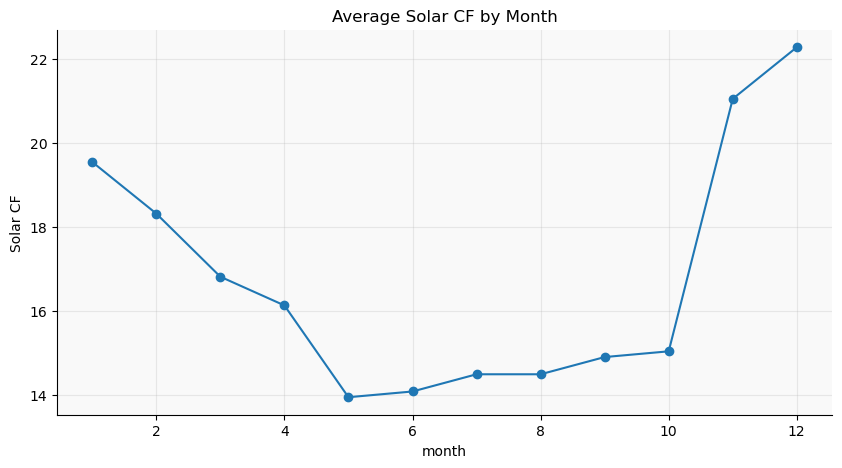

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# MONTHLY SEASONALITY
# ═══════════════════════════════════════════════════════════════════════
df['month'] = df.index.month

monthly_cf = (
    df.groupby('month')['solar_cf']
      .mean()
)

print(monthly_cf)

monthly_cf.plot(
    marker='o',
    figsize=(10,5),
    title='Average Solar CF by Month'
)

plt.ylabel('Solar CF')
plt.grid(True)

plt.show()

quarter
1    18.227273
2    14.727273
3    14.636364
4    19.454545
Name: solar_cf, dtype: float64


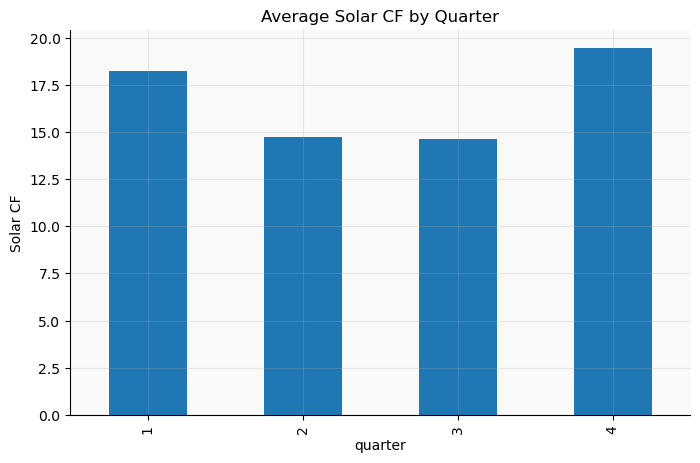

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# QUARTERLY SEASONALITY
# ═══════════════════════════════════════════════════════════════════════
df['quarter'] = df.index.quarter

quarterly_cf = (
    df.groupby('quarter')['solar_cf']
      .mean()
)

print(quarterly_cf)

quarterly_cf.plot(
    kind='bar',
    figsize=(8,5),
    title='Average Solar CF by Quarter'
)

plt.ylabel('Solar CF')

plt.grid(True)

plt.show()

In [41]:
# ═══════════════════════════════════════════════════════════════════════
# ANOVA TEST FOR MONTHLY SEASONALITY
# ═══════════════════════════════════════════════════════════════════════

from scipy.stats import f_oneway

monthly_groups = [
    group['solar_cf'].values
    for _, group in df.groupby(df.index.month)
]

f_stat, p_value = f_oneway(*monthly_groups)

print("\nANOVA RESULTS")
print("F-stat :", round(f_stat,4))
print("p-value:", round(p_value,6))


ANOVA RESULTS
F-stat : 28.9962
p-value: 0.0


In [42]:
solar_ardl = sel_solar.model.fit()

print(solar_ardl.summary())

                              ARDL Model Results                              
Dep. Variable:               solar_cf   No. Observations:                  132
Model:               ARDL(4, 1, 4, 4)   Log Likelihood                -111.396
Method:               Conditional MLE   S.D. of innovations              0.578
Date:                Tue, 09 Jun 2026   AIC                            258.793
Time:                        18:38:15   BIC                            310.129
Sample:                    05-01-2015   HQIC                           279.651
                         - 12-01-2025                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           28.0833      2.483     11.312      0.000      23.164      33.003
solar_cf.L1     -0.5531      0.084     -6.560      0.000      -0.720      -0.386
solar_cf.L2     -0.3235      0.068     -4.74

In [43]:
from statsmodels.tsa.ardl import UECM

solar_uecm = UECM.from_ardl(sel_solar.model)

solar_uecm_res = solar_uecm.fit()

print(solar_uecm_res.summary())

                              UECM Model Results                              
Dep. Variable:             D.solar_cf   No. Observations:                  132
Model:               UECM(4, 1, 4, 4)   Log Likelihood                -111.396
Method:               Conditional MLE   S.D. of innovations             16.977
Date:                Tue, 09 Jun 2026   AIC                            258.793
Time:                        18:38:15   BIC                            310.129
Sample:                    05-01-2015   HQIC                           279.651
                         - 12-01-2025                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             28.0833      2.483     11.312      0.000      23.164      33.003
solar_cf.L1       -2.1026      0.151    -13.931      0.000      -2.402      -1.803
dni.L1             0.7895      0.146

c:\Users\pc\miniconda3\envs\FE\Lib\site-packages\statsmodels\tsa\ardl\model.py:455: SpecificationWarning: exog contains variables that are missing from the order dictionary.  Missing keys: aerosol_od, precip_mm.
  return _format_order(self.data.orig_exog, order, self._causal)


In [44]:
solar_bt = solar_uecm_res.bounds_test(case=3)

print(solar_bt)

BoundsTestResult
Stat: 69.22978
Upper P-value: 0
Lower P-value: 0
Null: No Cointegration
Alternative: Possible Cointegration



c:\Users\pc\miniconda3\envs\FE\Lib\site-packages\statsmodels\tsa\ardl\model.py:455: SpecificationWarning: exog contains variables that are missing from the order dictionary.  Missing keys: aerosol_od, precip_mm.
  return _format_order(self.data.orig_exog, order, self._causal)


In [45]:
month_dummies = pd.get_dummies(
    df.index.month,
    prefix="m",
    drop_first=True
)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# MONTHLY DUMMY BENCHMARK MODEL
# can seasonality alon explain Solar CF?
# ═══════════════════════════════════════════════════════════════

import statsmodels.api as sm
import pandas as pd

month_dummies = pd.get_dummies(
    df.index.month,
    prefix='m',
    drop_first=True,
    dtype=float
)

# IMPORTANT
month_dummies.index = df.index

X = sm.add_constant(month_dummies)

seasonal_model = sm.OLS(
    df["solar_cf"],
    X
).fit()

print(seasonal_model.summary())

                            OLS Regression Results                            
Dep. Variable:               solar_cf   R-squared:                       0.727
Model:                            OLS   Adj. R-squared:                  0.702
Method:                 Least Squares   F-statistic:                     29.00
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           9.19e-29
Time:                        18:38:15   Log-Likelihood:                -256.43
No. Observations:                 132   AIC:                             536.9
Df Residuals:                     120   BIC:                             571.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.5455      0.534     36.611      0.0

the ARDL model performs better with superior AIC and BIC to this seasonality based model.

In [65]:
# ═══════════════════════════════════════════════════════════════
# SOLAR CF
# ARDL(4,1,4,4) + MONTHLY DUMMIES (L0 ONLY)
# ═══════════════════════════════════════════════════════════════

from statsmodels.tsa.ardl import ARDL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# MONTH DUMMIES
# -------------------------------------------------------------

month_dummies = pd.get_dummies(
    df.index.month,
    prefix="m",
    drop_first=True,
    dtype=float
)

month_dummies.index = df.index

# -------------------------------------------------------------
# EXOGENOUS MATRIX
# -------------------------------------------------------------

solar_exog = pd.concat(
    [
        df[
            [
                "dni",
                "harmattan",
                "temp_c"
            ]
        ],
        month_dummies
    ],
    axis=1
)

# -------------------------------------------------------------
# EXPLICIT LAG STRUCTURE
# -------------------------------------------------------------

solar_orders = {
    "dni": 1,
    "harmattan": 4,
    "temp_c": 4,

    # monthly dummies enter ONLY contemporaneously

    "m_2": 0,
    "m_3": 0,
    "m_4": 0,
    "m_5": 0,
    "m_6": 0,
    "m_7": 0,
    "m_8": 0,
    "m_9": 0,
    "m_10": 0,
    "m_11": 0,
    "m_12": 0
}

# -------------------------------------------------------------
# FIT MODEL
# -------------------------------------------------------------

solar_ardl_seasonal = ARDL(
    endog=df["solar_cf"],
    lags=4,
    exog=solar_exog,
    order=solar_orders,
    trend="c"
).fit()

print(solar_ardl_seasonal.summary())

# -------------------------------------------------------------
# AIC COMPARISON
# -------------------------------------------------------------

print("\n" + "="*60)
print("AIC COMPARISON")
print("="*60)

print("Original Solar ARDL AIC :", solar_ardl.aic)
print("Seasonal Solar ARDL AIC :", solar_ardl_seasonal.aic)


                                              ARDL Model Results                                             
Dep. Variable:                                              solar_cf   No. Observations:                  132
Model:             ARDL(4, 1, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)   Log Likelihood                 -56.343
Method:                                              Conditional MLE   S.D. of innovations              0.376
Date:                                               Tue, 09 Jun 2026   AIC                            170.685
Time:                                                       22:57:03   BIC                            253.394
Sample:                                                   05-01-2015   HQIC                           204.290
                                                        - 12-01-2025                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------

Adding the seasoning dummies without lags. So this becomes the final solar cf model

In [ ]:
solar_final = solar_ardl_seasonal

In [69]:
final_models = {
    "Gas Price": gas_final,
    "EAF": eaf_final_model,
    "Gas CF": gcf_final_model,
    "Solar CF": solar_ardl_seasonal,
    "Receivables": recv_final
}

for name in final_models:
    print(name, "✓")

Gas Price ✓
EAF ✓
Gas CF ✓
Solar CF ✓
Receivables ✓


---
## MODEL VALIDATION

Next, I'll validate these final models using tests like:
- Ljung-Box (white-noise residuals)
- Residual ACF
- Actual vs Fitted
- ARCH LM

Ljung-Box tests for Null Hypothesis, that is Residuals are independently distributed (white noise) and Alternative, that is Residual autocorrelation remains. decision rule is:
- p > 0.05 pass
- p < 0.05 fail

In [67]:
from statsmodels.stats.diagnostic import acorr_ljungbox

models = {
    "EAF": eaf_final_model,
    "Gas CF": gcf_final_model,
    "Receivables": recv_final,
    "Solar CF": solar_ardl_seasonal
}

for name, model in models.items():

    print("\n" + "="*60)
    print(name)
    print("="*60)

    result = acorr_ljungbox(
        model.resid,
        lags=[12],
        return_df=True
    )

    print(result)


EAF
     lb_stat  lb_pvalue
12  7.630648   0.813287

Gas CF
      lb_stat  lb_pvalue
12  22.062944    0.03682

Receivables
     lb_stat  lb_pvalue
12  6.933993   0.861945

Solar CF
      lb_stat  lb_pvalue
12  18.863152   0.091885


GAS CF fails, indicating that some information are still left in the residuals. the model hasn't completely captured the dynamic structure. The question becomes, is the remaining autocorrelation midl or severe? This will be answered by the next diagnosis

<Figure size 1000x500 with 0 Axes>

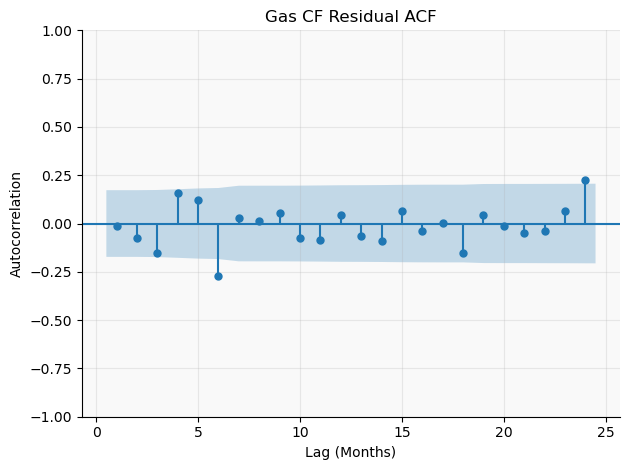

<Figure size 1000x500 with 0 Axes>

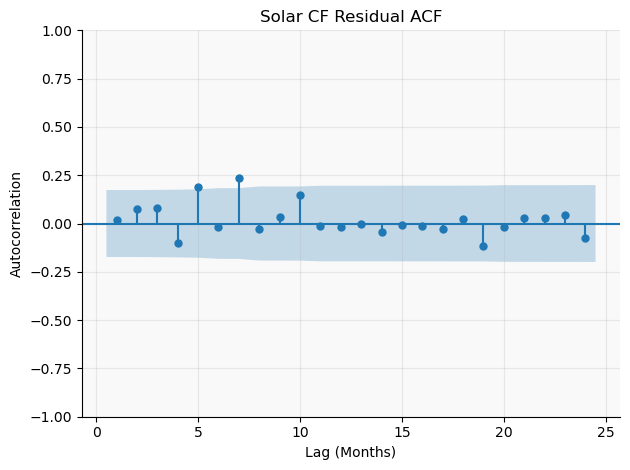

In [68]:
# ═══════════════════════════════════════════════════════════════
# RESIDUAL ACF DIAGNOSTICS
# Gas CF and Solar CF
# ═══════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

models = {
    "Gas CF": gcf_final_model.resid,
    "Solar CF": solar_ardl_seasonal.resid
}

for name, resid in models.items():

    plt.figure(figsize=(10,5))

    plot_acf(
        resid,
        lags=24,          # examine up to 2 years of monthly lags
        alpha=0.05,
        zero=False
    )

    plt.title(f"{name} Residual ACF")
    plt.xlabel("Lag (Months)")
    plt.ylabel("Autocorrelation")

    plt.tight_layout()
    plt.show()

Spikes outside the confidence bands are watched out for. For Gas Cf, we can see that most lags are comfortably inside the confidence bands. only oe lag is very minute especially with the other confluence report from ARDL, AIC, Johansen rank. 

- Does residual variance change as the model's predicted level changes

p > 0.05 pass (no evidence of heteroskedasticity)

p < 0.05 Fail (heteroskedasticity detected)

In [70]:
# ═══════════════════════════════════════════════════════════════
# BREUSCH-PAGAN HETEROSKEDASTICITY TEST
# EAF, Gas CF, Receivables, Solar CF
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# -------------------------------------------------------------
# MODEL LIST
# -------------------------------------------------------------

models = {
    "EAF": eaf_final_model,
    "Gas CF": gcf_final_model,
    "Receivables": recv_final,
    "Solar CF": solar_ardl_seasonal
}

# -------------------------------------------------------------
# BREUSCH-PAGAN
# -------------------------------------------------------------

results = []

for name, model in models.items():

    resid = model.resid

    # fitted values as explanatory variable
    exog_bp = sm.add_constant(model.fittedvalues)

    bp_test = het_breuschpagan(
        resid,
        exog_bp
    )

    lm_stat = bp_test[0]
    lm_pvalue = bp_test[1]
    f_stat = bp_test[2]
    f_pvalue = bp_test[3]

    results.append([
        name,
        lm_stat,
        lm_pvalue,
        f_stat,
        f_pvalue
    ])

bp_results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "LM Statistic",
        "LM p-value",
        "F Statistic",
        "F p-value"
    ]
)

print("\n" + "="*80)
print("BREUSCH-PAGAN HETEROSKEDASTICITY TEST")
print("="*80)

print(bp_results.round(4))


BREUSCH-PAGAN HETEROSKEDASTICITY TEST
         Model  LM Statistic  LM p-value  F Statistic  F p-value
0          EAF        0.1668      0.6829       0.1645     0.6857
1       Gas CF        1.7418      0.1869       1.7383     0.1897
2  Receivables        0.5861      0.4439       0.5798     0.4478
3     Solar CF        0.8656      0.3522       0.8579     0.3561


All four models pass, therefore there is no statistical evidence that residual variance changes systematically with the fitted values.

In [ ]:
# ═══════════════════════════════════════════════════════════════
# JARQUE-BERA NORMALITY TEST
# EAF, Gas CF, Receivables, Solar CF
# p > 0.05 - Cannot reject normality
# p < 0.05 - Residuals are non-normal
# ═══════════════════════════════════════════════════════════════

import pandas as pd
from scipy.stats import jarque_bera, skew, kurtosis

# -------------------------------------------------------------
# MODEL LIST
# -------------------------------------------------------------

models = {
    "EAF": eaf_final_model,
    "Gas CF": gcf_final_model,
    "Receivables": recv_final,
    "Solar CF": solar_ardl_seasonal
}

# -------------------------------------------------------------
# JARQUE-BERA TEST
# -------------------------------------------------------------

results = []

for name, model in models.items():

    resid = model.resid

    jb_stat, jb_pvalue = jarque_bera(resid)

    resid_skew = skew(resid)

    resid_kurt = kurtosis(
        resid,
        fisher=False   # normal = 3
    )

    results.append([
        name,
        jb_stat,
        jb_pvalue,
        resid_skew,
        resid_kurt
    ])

jb_results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "JB Statistic",
        "JB p-value",
        "Skewness",
        "Kurtosis"
    ]
)

print("\n" + "="*80)
print("JARQUE-BERA NORMALITY TEST")
print("="*80)

print(jb_results.round(4))


JARQUE-BERA NORMALITY TEST
         Model  JB Statistic  JB p-value  Skewness  Kurtosis
0          EAF      201.4790         0.0   -0.5056    9.0144
1       Gas CF      372.8918         0.0   -0.2152   11.3180
2  Receivables     8451.6476         0.0    1.5104   42.2335
3     Solar CF      214.0971         0.0    0.3031    9.3068


- EAF model is moderately left-skewed, Extremely above normal Kurtosis, in summary residuals are not Gaussian.
- Gas CF is almost symmetric with very heavy tails. 
- Receivables has strong positive skew and extraordinary kurtosis (42.23). They are highly non-Gaussian.
- Solar CF has nearly symmetric skewness, heavy tail kurtosis.

This model is built for forecasting, scenario analysis, monte carlo simulation and copula modeling, thus the residuals not being normally distributed isn't a model failure. Real systems experience occassional lage shocks, Receivables are notorious for occasional explosive movements, cloud systems are not normally distributed.

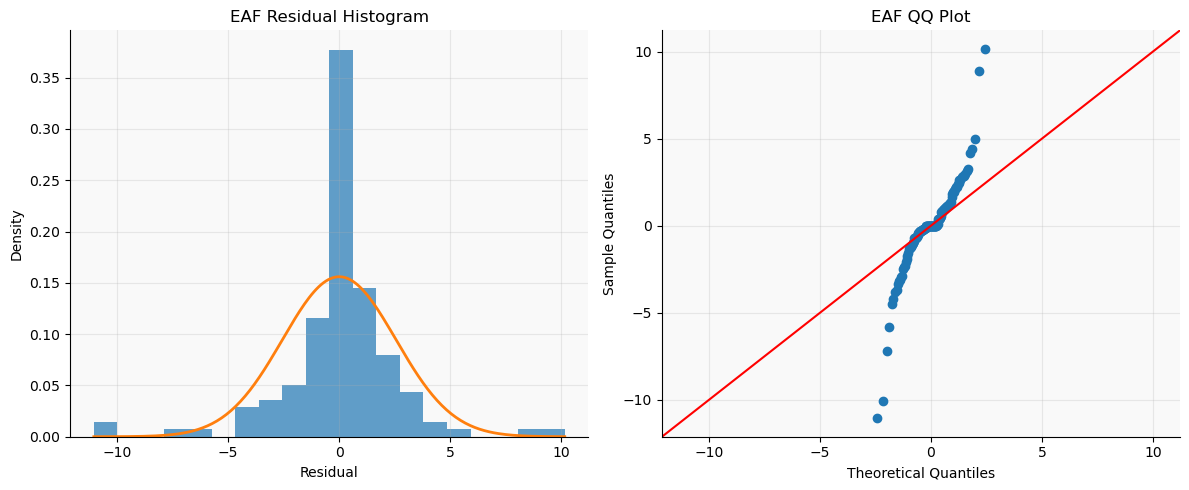

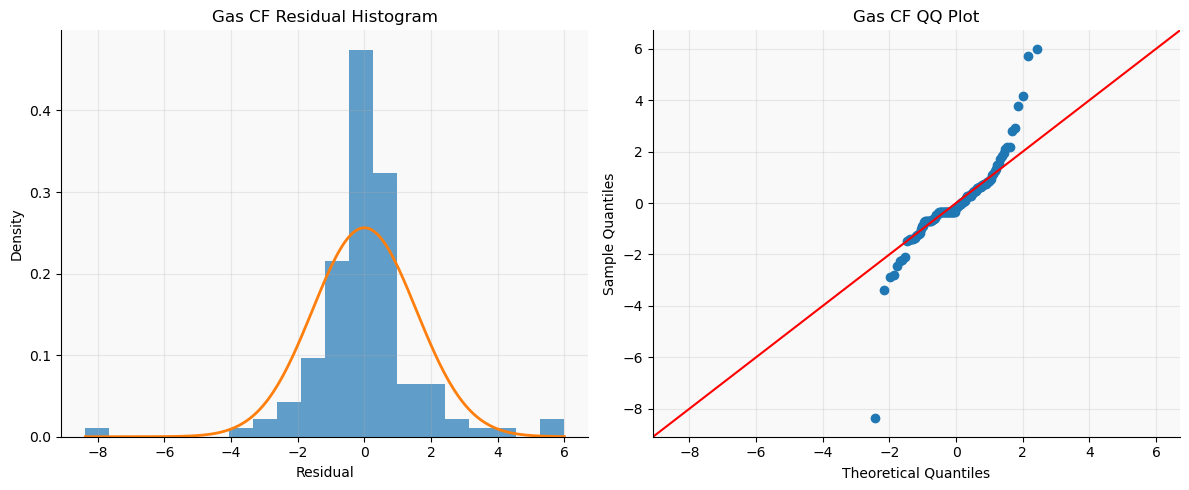

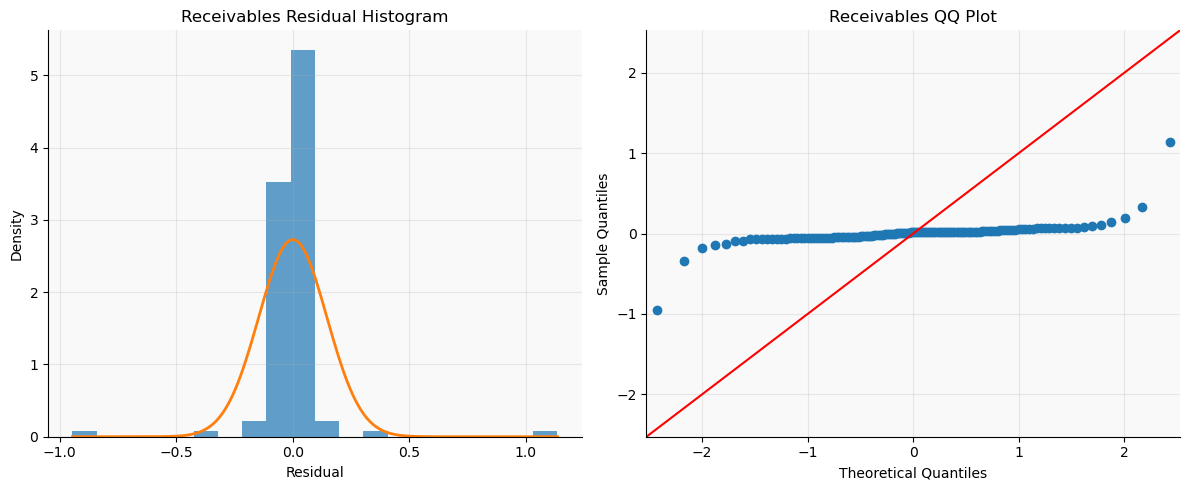

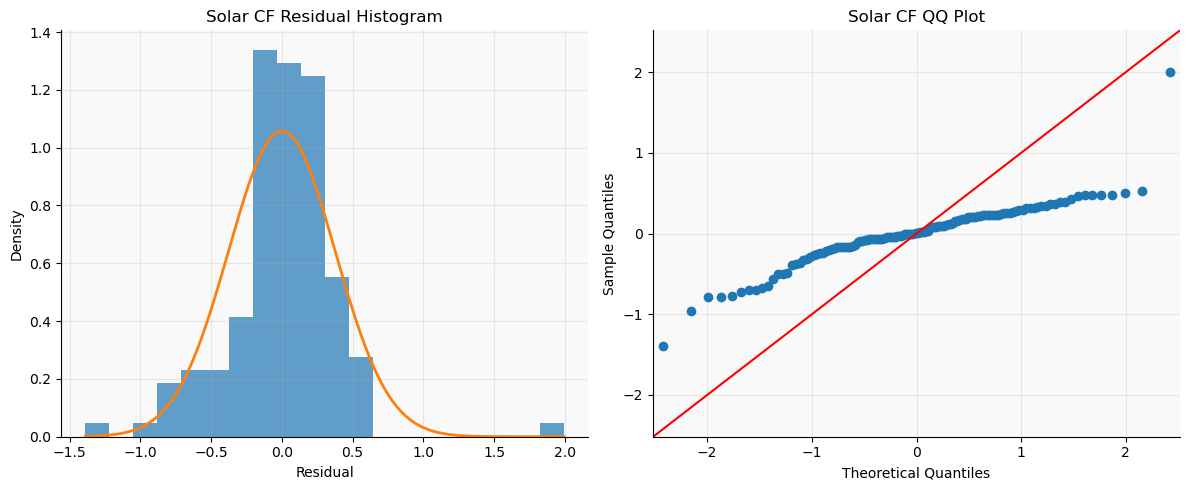

In [72]:
# ═══════════════════════════════════════════════════════════════
# RESIDUAL HISTOGRAMS + QQ PLOTS
# EAF, Gas CF, Receivables, Solar CF
# ═══════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from scipy.stats import norm
import statsmodels.api as sm

# -------------------------------------------------------------
# MODEL LIST
# -------------------------------------------------------------

models = {
    "EAF": eaf_final_model,
    "Gas CF": gcf_final_model,
    "Receivables": recv_final,
    "Solar CF": solar_ardl_seasonal
}

# -------------------------------------------------------------
# HISTOGRAM + QQ PLOT
# -------------------------------------------------------------

for name, model in models.items():

    resid = model.resid

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12,5)
    )

    # =========================================================
    # HISTOGRAM
    # =========================================================

    axes[0].hist(
        resid,
        bins=20,
        density=True,
        alpha=0.7
    )

    mu = resid.mean()
    sigma = resid.std()

    x = np.linspace(
        resid.min(),
        resid.max(),
        200
    )

    axes[0].plot(
        x,
        norm.pdf(x, mu, sigma),
        linewidth=2
    )

    axes[0].set_title(
        f"{name} Residual Histogram"
    )

    axes[0].set_xlabel("Residual")
    axes[0].set_ylabel("Density")

    # =========================================================
    # QQ PLOT
    # =========================================================

    sm.qqplot(
        resid,
        line="45",
        ax=axes[1]
    )

    axes[1].set_title(
        f"{name} QQ Plot"
    )

    plt.tight_layout()
    plt.show()

In [74]:
recv_final.resid.sort_values()

2017-10-01   -0.945388
2021-04-01   -0.343198
2019-02-01   -0.184815
2024-01-01   -0.140069
2019-04-01   -0.136023
                ...   
2019-07-01    0.110355
2023-01-01    0.143811
2019-03-01    0.196366
2024-04-01    0.327889
2025-01-01    1.135167
Length: 131, dtype: float64

The evidence from  Receivables model suggests no residual autocorrelation, no heteroskedasticity, no catastrophic outliers and non-normality driven by concentration and tail shape rather than model failure.

Next to check the structural fitting of the models, i'd run an Actual vs Fitted Plots. Can the model reproduce the behavior of the system?

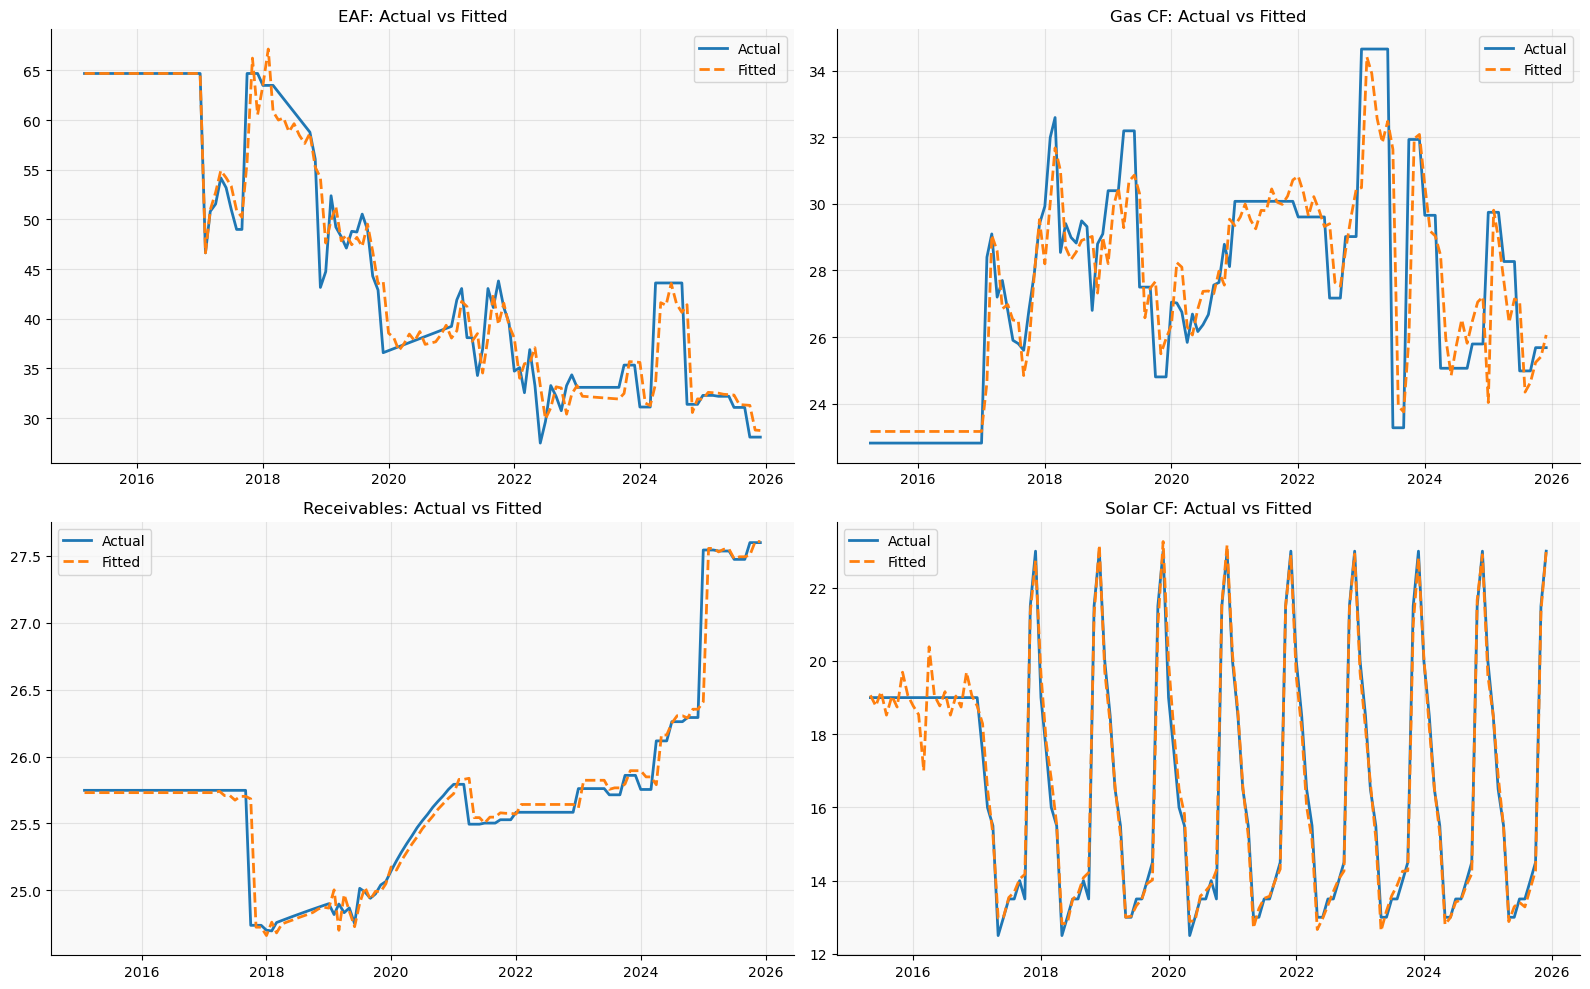

In [75]:
# ═══════════════════════════════════════════════════════════════
# ACTUAL vs FITTED PLOTS
# EAF, Gas CF, Receivables, Solar CF
# ═══════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

# -------------------------------------------------------------
# MODEL DEFINITIONS
# -------------------------------------------------------------

models = {
    "EAF": (
        df["eaf"],
        eaf_final_model.fittedvalues
    ),

    "Gas CF": (
        df["gas_cf"],
        gcf_final_model.fittedvalues
    ),

    "Receivables": (
        df["ln_receivables"],
        recv_final.fittedvalues
    ),

    "Solar CF": (
        df["solar_cf"],
        solar_ardl_seasonal.fittedvalues
    )
}

# -------------------------------------------------------------
# PLOT
# -------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16,10)
)

axes = axes.flatten()

for ax, (name, (actual, fitted)) in zip(axes, models.items()):

    # align indices
    common_idx = actual.index.intersection(fitted.index)

    actual_aligned = actual.loc[common_idx]
    fitted_aligned = fitted.loc[common_idx]

    ax.plot(
        actual_aligned.index,
        actual_aligned,
        label="Actual",
        linewidth=2
    )

    ax.plot(
        fitted_aligned.index,
        fitted_aligned,
        label="Fitted",
        linewidth=2,
        linestyle="--"
    )

    ax.set_title(f"{name}: Actual vs Fitted")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

These models exhibit very good and operationally sound.

Next, we run the RMSE (penalizes large errors heavily), MAE (average magnitude of errors) and MAPE (percentage error, easiest for readers to interpret)

In [76]:
# ═══════════════════════════════════════════════════════════════
# FORECAST ACCURACY METRICS
# RMSE, MAE, MAPE
# EAF, Gas CF, Receivables, Solar CF
# ═══════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# -------------------------------------------------------------
# MODEL DEFINITIONS
# -------------------------------------------------------------

models = {
    "EAF": (
        df["eaf"],
        eaf_final_model.fittedvalues
    ),

    "Gas CF": (
        df["gas_cf"],
        gcf_final_model.fittedvalues
    ),

    "Receivables": (
        df["ln_receivables"],
        recv_final.fittedvalues
    ),

    "Solar CF": (
        df["solar_cf"],
        solar_ardl_seasonal.fittedvalues
    )
}

# -------------------------------------------------------------
# METRICS
# -------------------------------------------------------------

results = []

for name, (actual, fitted) in models.items():

    # align observations
    common_idx = actual.index.intersection(fitted.index)

    y_true = actual.loc[common_idx]
    y_pred = fitted.loc[common_idx]

    # RMSE
    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    # MAE
    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    # MAPE
    # avoid division-by-zero problems
    mask = y_true != 0

    mape = (
        np.mean(
            np.abs(
                (y_true[mask] - y_pred[mask])
                / y_true[mask]
            )
        )
        * 100
    )

    results.append([
        name,
        rmse,
        mae,
        mape
    ])

accuracy_table = pd.DataFrame(
    results,
    columns=[
        "Model",
        "RMSE",
        "MAE",
        "MAPE (%)"
    ]
)

print("\n" + "="*80)
print("FORECAST ACCURACY METRICS")
print("="*80)

print(
    accuracy_table.round(4)
)


FORECAST ACCURACY METRICS
         Model    RMSE     MAE  MAPE (%)
0          EAF  2.5481  1.5278    3.7916
1       Gas CF  1.5512  0.9743    3.5033
2  Receivables  0.1456  0.0622    0.2418
3     Solar CF  0.3758  0.2598    1.5714


These are excellent results. This suggests that the residual autocorrelation detected by Ljung-Box is not materially degrading forecasting performance. 

Only one diagnostic still has realistic potential to affect downstream modeling decisions. The ARCH LM Test because it can answer "Are residual variances independent through time"? This can affect Monte carlo design, Residual simulation strategy or Copula inputs may need volatility treatment.

p > 0.05 = No ARCH effects(pass)
P < 0.05 = ARCH effects present (Fail)

In [78]:
# ═══════════════════════════════════════════════════════════════
# ARCH LM TEST
# EAF, Gas CF, Receivables, Solar CF
# ═══════════════════════════════════════════════════════════════

import pandas as pd
from statsmodels.stats.diagnostic import het_arch

# -------------------------------------------------------------
# MODEL LIST
# -------------------------------------------------------------

models = {
    "EAF": eaf_final_model,
    "Gas CF": gcf_final_model,
    "Receivables": recv_final,
    "Solar CF": solar_ardl_seasonal
}

# -------------------------------------------------------------
# ARCH LM TEST
# -------------------------------------------------------------

results = []

for name, model in models.items():

    resid = model.resid

    arch_test = het_arch(
        resid,
        nlags=12
    )

    lm_stat = arch_test[0]
    lm_pvalue = arch_test[1]

    f_stat = arch_test[2]
    f_pvalue = arch_test[3]

    results.append([
        name,
        lm_stat,
        lm_pvalue,
        f_stat,
        f_pvalue
    ])

arch_results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "LM Statistic",
        "LM p-value",
        "F Statistic",
        "F p-value"
    ]
)

print("\n" + "="*80)
print("ARCH LM TEST")
print("="*80)

print(
    arch_results.round(4)
)


ARCH LM TEST
         Model  LM Statistic  LM p-value  F Statistic  F p-value
0          EAF        7.2502      0.8406       0.5728     0.8596
1       Gas CF       16.2067      0.1820       1.3935     0.1807
2  Receivables        0.8523      1.0000       0.0637     1.0000
3     Solar CF       19.7419      0.0721       1.7604     0.0648


Solar CF (p = 0.0648) shows a very mild evidence of volatility clustering, but not statistically significant at the conventional 5% level

---
## Forecasting Errors

In [87]:
# ==========================================================
# RESIDUAL EXTRACTION
# ==========================================================

#gas_resid   = gas_final.resid
eaf_resid   = eaf_final_model.resid
gcf_resid   = gcf_final_model.resid
solar_resid = solar_ardl_seasonal.resid
recv_resid  = recv_final.resid

print("Residuals extracted")

Residuals extracted


In [88]:
# ==========================================================
# RESIDUAL LENGTHS
# ==========================================================

#print("Gas Price   :", len(gas_resid))
print("EAF         :", len(eaf_resid))
print("Gas CF      :", len(gcf_resid))
print("Solar CF    :", len(solar_resid))
print("Receivables :", len(recv_resid))

EAF         : 130
Gas CF      : 129
Solar CF    : 128
Receivables : 131


In [89]:
# ==========================================================
# MASTER RESIDUAL DATASET
# ==========================================================

residuals = pd.concat(
    [
        #gas_resid.rename("gas_price"),
        eaf_resid.rename("eaf"),
        gcf_resid.rename("gas_cf"),
        solar_resid.rename("solar_cf"),
        recv_resid.rename("receivables")
    ],
    axis=1
)

residuals = residuals.dropna()

print(residuals.shape)

residuals.head()

(128, 4)


,eaf,gas_cf,solar_cf,receivables
2015-05-01,-2.692265e-08,-0.349372,-0.063153,0.017129
2015-06-01,-2.692265e-08,-0.349372,0.227494,0.017129
2015-07-01,-2.692265e-08,-0.349372,-0.161687,0.017129
2015-08-01,-2.692265e-08,-0.349372,0.477927,0.017129
2015-09-01,-2.692265e-08,-0.349372,-0.043369,0.017129


In [92]:
print(residuals.head(15))

                     eaf    gas_cf  solar_cf  receivables
2015-05-01 -2.692265e-08 -0.349372 -0.063153     0.017129
2015-06-01 -2.692265e-08 -0.349372  0.227494     0.017129
2015-07-01 -2.692265e-08 -0.349372 -0.161687     0.017129
2015-08-01 -2.692265e-08 -0.349372  0.477927     0.017129
2015-09-01 -2.692265e-08 -0.349372 -0.043369     0.017129
2015-10-01 -2.692265e-08 -0.349372  0.256869     0.017129
2015-11-01 -2.692265e-08 -0.349372 -0.694082     0.017129
2015-12-01 -2.692265e-08 -0.349372 -0.063153     0.017129
2016-01-01 -2.692265e-08 -0.349372  0.227494     0.017129
2016-02-01 -2.692265e-08 -0.349372  0.463250     0.017129
2016-03-01 -2.692265e-08 -0.349372  1.995979     0.017129
2016-04-01 -2.692265e-08 -0.349372 -1.388163     0.017129
2016-05-01 -2.692265e-08 -0.349372 -0.063153     0.017129
2016-06-01 -2.692265e-08 -0.349372  0.227494     0.017129
2016-07-01 -2.692265e-08 -0.349372 -0.161687     0.017129


In [93]:
print(residuals.tail(15))

                  eaf    gas_cf  solar_cf  receivables
2024-10-01 -10.030948 -0.685304  0.310650     0.004032
2024-11-01   0.823603 -1.262859 -0.165372    -0.061940
2024-12-01  -0.550693 -1.416980  0.098735    -0.061940
2025-01-01   0.389345  5.721398  0.392159     1.135167
2025-02-01  -0.307202 -0.063684 -0.000202    -0.011956
2025-03-01  -0.267162  0.803179 -0.363944    -0.011956
2025-04-01  -0.317130  0.598755  0.029080     0.006464
2025-05-01  -0.203430  1.831714  0.118159    -0.013336
2025-06-01  -0.163393  1.125814 -0.288525    -0.013336
2025-07-01  -1.243355 -2.084197  0.093300    -0.004206
2025-08-01  -0.286679  0.637321  0.216419    -0.019145
2025-09-01  -0.246639  0.345394  0.206740    -0.019145
2025-10-01  -3.196607  0.442262  0.222259     0.093126
2025-11-01  -0.709470  0.272746  0.134310    -0.008067
2025-12-01  -0.669432 -0.381419 -0.001057    -0.008067


                  eaf    gas_cf  solar_cf  receivables
eaf          1.000000 -0.000788 -0.056395    -0.095693
gas_cf      -0.000788  1.000000  0.002750     0.154105
solar_cf    -0.056395  0.002750  1.000000     0.089828
receivables -0.095693  0.154105  0.089828     1.000000


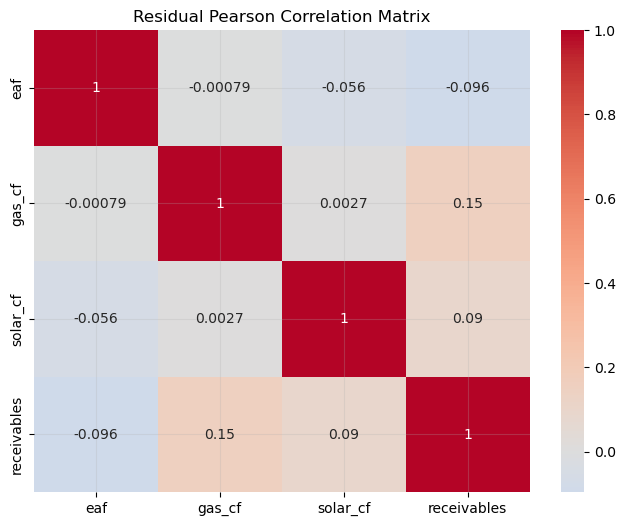

In [90]:
# ==========================================================
# PEARSON CORRELATION
# Is there obvious dependence remaining among innovations?
# ==========================================================

pearson_resid = residuals.corr()

print(pearson_resid)

plt.figure(figsize=(8,6))
sns.heatmap(
    pearson_resid,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Residual Pearson Correlation Matrix")
plt.show()

                  eaf    gas_cf  solar_cf  receivables
eaf          1.000000  0.034705 -0.065139    -0.035173
gas_cf       0.034705  1.000000 -0.009721    -0.037429
solar_cf    -0.065139 -0.009721  1.000000    -0.185913
receivables -0.035173 -0.037429 -0.185913     1.000000


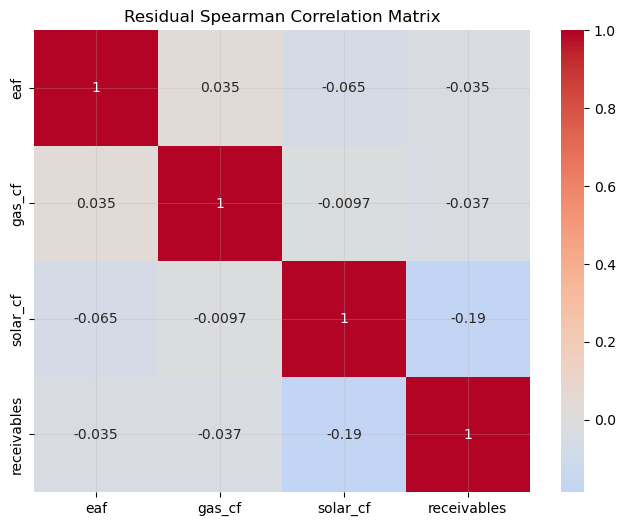

In [91]:
# ==========================================================
# SPEARMAN CORRELATION
# ==========================================================

spearman_resid = residuals.corr(
    method="spearman"
)

print(spearman_resid)

plt.figure(figsize=(8,6))
sns.heatmap(
    spearman_resid,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Residual Spearman Correlation Matrix")
plt.show()

In [94]:
print(eaf_resid.sample(20))

print(gcf_resid.sample(20))

print(solar_resid.sample(20))

2021-10-01    4.383545e+00
2024-10-01   -1.003095e+01
2018-01-01   -1.526557e-02
2016-01-01   -2.692265e-08
2024-05-01    1.988858e+00
2022-06-01   -5.784317e+00
2020-06-01    3.694172e-02
2016-08-01   -2.692265e-08
2022-03-01   -2.916775e+00
2025-07-01   -1.243355e+00
2021-04-01   -3.129877e+00
2018-09-01    1.796406e+00
2023-10-01    2.853608e+00
2020-11-01    4.225679e-01
2021-01-01    1.177568e+00
2015-04-01   -2.692265e-08
2018-04-01    2.808651e+00
2017-09-01   -1.225116e+00
2015-12-01   -2.692265e-08
2019-10-01   -2.487458e+00
dtype: float64
2017-01-01   -0.349372
2016-06-01   -0.349372
2024-05-01   -0.891125
2016-11-01   -0.349372
2025-06-01    1.125814
2019-03-01   -0.084194
2023-04-01    2.085993
2018-05-01    0.717167
2017-06-01   -0.175858
2018-08-01    0.588993
2015-07-01   -0.349372
2021-10-01    0.091677
2015-04-01   -0.349372
2019-05-01    1.520257
2022-02-01   -0.715480
2015-06-01   -0.349372
2020-09-01    0.257696
2019-12-01   -1.151350
2025-01-01    5.721398
2024-04-

In [97]:
# residuals output
residuals = pd.concat(
    [
        eaf_resid.rename("eaf"),
        gcf_resid.rename("gas_cf"),
        solar_resid.rename("solar_cf"),
        recv_resid.rename("receivables")
    ],
    axis=1
).dropna()

Up next, i'll use a copula, not because the residual dependence is strong but because it can capture rank dependence, nonlinear dependence and tail co-movement even when linear correlations are small (as shown in above). But before fitting a copula, we need to understand the probability distribution of each model's forecast error.
*Residual Distribution Analysis* answers the question, what distribution best describes each residual series?

Creating Pseudo-Observatons as an important preprocessing step in copula modeling. A copula models the dependence structure after removing the marginal distributions.

In [109]:
# ==========================================================
# CONSTRUCT PSEUDO-OBSERVATIONS
# ==========================================================

from scipy.stats import rankdata

# residuals contains:
# eaf
# gas_cf
# solar_cf
# receivables

u = residuals.copy()

n = len(u)

for col in u.columns:

    u[col] = (
        rankdata(
            u[col],
            method="average"
        )
        /
        (n + 1)
    )

print("Pseudo-observations created")
print()

print(u.head())

print("\nShape:")
print(u.shape)

print(
    u.describe().round(4)
)

Pseudo-observations created

                 eaf    gas_cf  solar_cf  receivables
2015-05-01  0.503876  0.395349  0.344961     0.620155
2015-06-01  0.503876  0.395349  0.740310     0.620155
2015-07-01  0.503876  0.395349  0.259690     0.620155
2015-08-01  0.503876  0.395349  0.957364     0.620155
2015-09-01  0.503876  0.395349  0.399225     0.620155

Shape:
(128, 4)
            eaf    gas_cf  solar_cf  receivables
count  128.0000  128.0000  128.0000     128.0000
mean     0.5000    0.5000    0.5000       0.5000
std      0.2869    0.2869    0.2876       0.2866
min      0.0078    0.0078    0.0078       0.0078
25%      0.2539    0.2539    0.2568       0.2519
50%      0.5039    0.5000    0.5000       0.5000
75%      0.7461    0.7461    0.7442       0.7461
max      0.9922    0.9922    0.9922       0.9922


before fitting the copula, we need to answer "How much dependence remains among the innovations after the ARDL models have explained the system dynamics?". This is where Kendall's Tau comes in because copulas are rank-based, Tau is invariant to monotonic transformations, Tau is more robust than Pearon correlation.

Kendall Tau Matrix

                eaf  gas_cf  solar_cf  receivables
eaf          1.0000  0.0104   -0.0399      -0.0065
gas_cf       0.0104  1.0000   -0.0055      -0.0294
solar_cf    -0.0399 -0.0055    1.0000      -0.1256
receivables -0.0065 -0.0294   -0.1256       1.0000


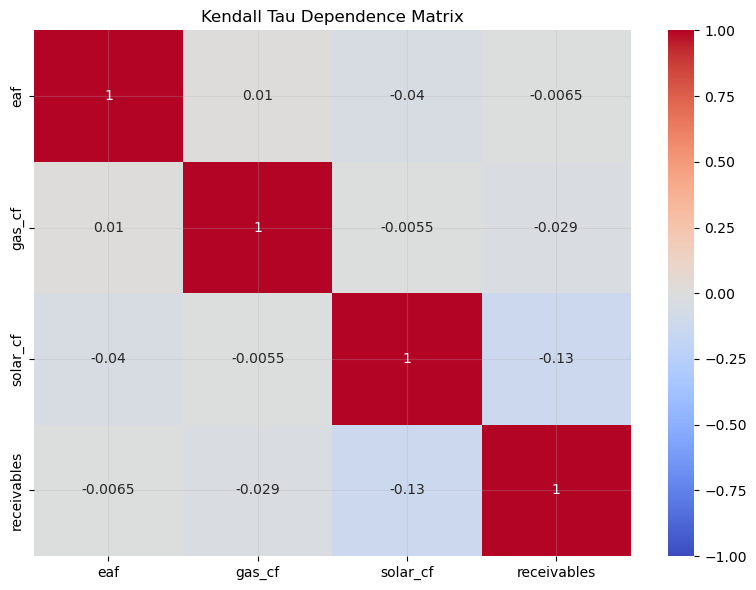

In [110]:
# ==========================================================
# KENDALL TAU DEPENDENCE ANALYSIS
# ==========================================================

import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# KENDALL TAU MATRIX
# ----------------------------------------------------------

tau = u.corr(method="kendall")

print("Kendall Tau Matrix")
print()
print(tau.round(4))

# ----------------------------------------------------------
# HEATMAP
# ----------------------------------------------------------

plt.figure(figsize=(8,6))

sns.heatmap(
    tau,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Kendall Tau Dependence Matrix")

plt.tight_layout()
plt.show()

This output shows that the ARDL models have absorbed mosr systematic dependence. Leaving only residual dependence for Copula to model.

Even though average dependence is weak, do extreme events occur together? This is precisely what Student-t copulas are designed to capture.

In [111]:
# ==========================================================
# TAIL DEPENDENCE EXPLORATION
# ==========================================================

import pandas as pd
from itertools import combinations

# ----------------------------------------------------------
# THRESHOLDS
# ----------------------------------------------------------

upper_q = 0.95
lower_q = 0.05

results = []

# ----------------------------------------------------------
# PAIRWISE TAIL DEPENDENCE
# ----------------------------------------------------------

for x, y in combinations(u.columns, 2):

    upper_joint = (
        (u[x] > upper_q)
        &
        (u[y] > upper_q)
    ).sum()

    lower_joint = (
        (u[x] < lower_q)
        &
        (u[y] < lower_q)
    ).sum()

    upper_rate = upper_joint / len(u)

    lower_rate = lower_joint / len(u)

    results.append([
        x,
        y,
        upper_joint,
        lower_joint,
        upper_rate,
        lower_rate
    ])

tail_dep = pd.DataFrame(
    results,
    columns=[
        "Variable 1",
        "Variable 2",
        "Upper Tail Count",
        "Lower Tail Count",
        "Upper Tail Rate",
        "Lower Tail Rate"
    ]
)

print("\nTAIL DEPENDENCE EXPLORATION\n")

print(
    tail_dep.round(4)
)


TAIL DEPENDENCE EXPLORATION

  Variable 1   Variable 2  Upper Tail Count  Lower Tail Count  \
0        eaf       gas_cf                 0                 0   
1        eaf     solar_cf                 0                 0   
2        eaf  receivables                 1                 1   
3     gas_cf     solar_cf                 0                 0   
4     gas_cf  receivables                 2                 0   
5   solar_cf  receivables                 0                 0   

   Upper Tail Rate  Lower Tail Rate  
0           0.0000           0.0000  
1           0.0000           0.0000  
2           0.0078           0.0078  
3           0.0000           0.0000  
4           0.0156           0.0000  
5           0.0000           0.0000  


this extreme weak evidence plus that from Kendall Tau, it's almost certain there's no tail co-occurrence. The Residual innovvation system appears to be nearly independent. With this and for rigor, The question for copula which i "How do residual shocks occurr together?, the diagnostics Kendrall Tau and Tail dependence are currently saying they largely don't. Because the dependence signal is extremely weak, we'll move away from an Copula analysis.